# Introduction to Machine Learning -- MC886
# Assignment 1 - Linear Models

**Professor:** Marcelo da Silva Reis\
**PED:** Heigon Alafaire Soldera Pires


In [34]:
# Please, enter your name and RA number in the lines below:
print("Lucas Treviso Bandeira", "|", "322979")
print("Mariana Dourado Ximenes de Sena Santos", "|", "300643")

Lucas Treviso Bandeira | 322979
Mariana Dourado Ximenes de Sena Santos | 300643



## Objective

The objective with this assignment is to explore **Linear Regression** and other
**Generalized Linear Models** to come up with the best model for the problem.
Remember, the goal is not just getting the code running, but gathering a deeper
understanding on **how** these algorithms work and **why** choosing them in the
first place.

Every model choice has implicit assumptions about the data, the goal here is to
understand the underlying assumptions and critically address the limitations
introduced by them.

### **Guidelines**
> Please, read these guidelines carefully

1. The questions can be answered in English or in Portuguese.

2. We incentivize visualizing the (training) data to gather insight about the
problem and the solutions. If you are not sure about an assumption, plot it!

3. The existing code in this notebook is just a mere reference. You are free to
change the code as much as you need. You will not be penalized for changing a 
function signature or implementing more functions/classes.
**Just make the code readable!**

4. The use of generative AI (ChatGPT, DeepSeek, Llama, GitHub Copilot, etc.) is
permitted to assist in completing assignments. In such cases the submitted work
**must** include a statement specifying the models used and, if
applicable, a transcription of the prompts employed to generate the code
incorporated into the solution.
However, using AI to analyse and discuss the results is discouraged.

5. The final performance of your model is not the main goal, explaining why the
model has such a performance (it being good or bad) is more important than the
metric value per se.

6. Metrics are not detached values, revisit the math behind them to understand
what they are trying to say about your model.

7. Do not hesitate in reaching the PED via Discord.

---
### **Dataset**
The dataset we will be using is the [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
dataset, an hourly count of vehicles on the westbound Interstate 94, measured by
the MnDOT sensor ATR 301, roughly midway between Minneapolis and St. Paul (MN),
between 2015 and 2018.
Each observation joins the traffic counter with the weather reported for that
same hour and with the holiday calendar.

The data has 26677 samples with the following columns

feature | description | data type
--- | --- | ---
**instant** | Integer identifier | Integer
**date** | Date of the observation | Date
**season** | The season (1 Winter, 2 Spring, 3 Summer, 4 Fall) | Categorical
**yr** | Year (0 for 2015, 1 for 2016, 2 for 2017 and 3 for 2018) | Categorical
**mnth** | The month number | Categorical
**hr** | The hour number | Categorical
**holiday** | Whether the day is a national holiday (or the Minnesota State Fair) | Boolean
**weekday** | The day of the week (0 is Sunday) | Categorical
**workingday** | If the day is neither a holiday nor a weekend | Boolean
**weather** | Current weather (Clear, Clouds, Rain, Snow, Mist, ...) | Categorical
**weather_desc** | A longer description of the current weather | Categorical
**temp** | Temperature in °C | Continuous
**rain_1h** | Rain that fell during the hour, in mm | Continuous
**snow_1h** | Snow that fell during the hour, in mm | Continuous
**clouds_all** | Cloud cover in % | Continuous
**traffic_volume** | Count of vehicles reported in the hour | Integer

The goal will be inferring the traffic volume of an hour only using datetime and
weather information provided in the dataset.

> **Note:** this data comes from real sensors and was only lightly cleaned for
> you. Some hours are absent from the record and a few readings are physically
> implausible. Deciding what (if anything) to do about them is part of the
> assignment.

*Source: Hogue, J. (2019). Metro Interstate Traffic Volume. UCI Machine Learning
Repository (CC BY 4.0).*


In [35]:
# Importing the necessary libraries
# Remember to re-visit the Hands-on 1 notebooks to setup your environment
from numpy.typing import NDArray
import numpy as np

import pandas as pd
import random

# This notebook already has some plot examples in matplotlib, but feel free to
# use other libraries (e.g., seaborn, plotly) if you prefer
import matplotlib.pyplot as plt
import seaborn as sns

# To ensure reproducibility, set the random seed to your
# favorite number (e.g., your RA number)
np.random.seed(42)
random.seed(42)

# Do not tune this number to get better results, it is just to ensure that
# we all have the same random numbers and, therefore, the same results
# Re-run the notebook from the beginning (Run All) before submitting to classroom

In [36]:
# The dataset is available in the classroom assignment, ensure you have downloaded
# it and placed it in the same folder as this notebook

# Load the dataset
df = pd.read_csv("traffic_volume.csv")

df["date"] = pd.to_datetime(df["date"])
df.head()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,1,2015-06-11,3,0,6,20,0,4,1,Rain,light rain,14.44,0.0,0.0,92,2886
1,2,2015-06-12,3,0,6,18,0,5,1,Clear,Sky is Clear,24.39,0.0,0.0,0,4380
2,3,2015-06-12,3,0,6,20,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3095
3,4,2015-06-12,3,0,6,21,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3299
4,5,2015-06-13,3,0,6,21,0,6,0,Clouds,broken clouds,21.69,0.0,0.0,76,3040


Note that the data is time-ordered, and consecutive samples are (usually) 1 hour
apart from each other. Beware that the record is not perfectly regular: some
hours were never reported by the sensor.
The idea is to predict future traffic volume from past data, thus our evaluation
protocol must respect the temporal order.
Therefore, we select the first 80% samples to compose the training data, and the
remaining 20% will be used for testing purposes.

**Important:** Never take decisions over the test dataset, it must be only used after
all models are trained (in the Test Evaluation section).
Any decision made using test information is called [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)) and will be penalized.


In [37]:
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

# Securing that df will not be used anymore, to avoid mistakes
del df

print("Train set size:", len(train_df))
print("Test set size:", len(test_df))

Train set size: 21341
Test set size: 5336


---

## **Data Analysis and Preprocessing**

This part of the assignment aims to analyze the dataset and preprocess
the data for the models.


(0.5 points) 
First, consider possible problems in your dataset:
- Should you use all the features in the dataset?
- What features are important, are there missing values in them?
- Are there outliers in continous features?
- How should you handle the categorical features?
- How does the traffic volume change when features change?
- Are these feature correlated?

Do not plot any graph for now, just see some statistics (mean, count, data types).
You can manually explore the dataframe if you want.

In [38]:
train_df.describe()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,21341.000000,21341,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000
mean,10671.000000,2016-11-16 00:53:50.738953,2.574809,1.352092,6.813177,11.471346,0.032707,3.000984,0.680943,9.058459,0.520919,0.000223,41.742749,3277.748981
min,1.000000,2015-06-11 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-29.760000,0.000000,0.000000,0.000000,0.000000
25%,5336.000000,2016-04-16 00:00:00,1.000000,1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,1.000000,1250.000000
50%,10671.000000,2016-11-29 00:00:00,3.000000,1.000000,7.000000,11.000000,0.000000,3.000000,1.000000,11.080000,0.000000,0.000000,40.000000,3446.000000
75%,16006.000000,2017-07-12 00:00:00,4.000000,2.000000,10.000000,18.000000,0.000000,5.000000,1.000000,19.170000,0.000000,0.000000,90.000000,4915.000000
max,21341.000000,2018-02-19 00:00:00,4.000000,3.000000,12.000000,23.000000,1.000000,6.000000,1.000000,34.180000,9831.300000,0.510000,100.000000,7280.000000
std,6160.760383,NaN,1.143291,0.822834,3.447233,6.953911,0.177873,2.002400,0.466122,12.523845,67.301383,0.007825,39.245090,1964.269523


In [39]:
# Auxiliary code to display extra information about the dataset

print("DataFrame data types summary:\n\n{}\n".format(train_df.dtypes))

print("Number of missing values in train_df:\n{}\n".format(train_df.isna().sum().sum()))

print("Number of unique values in train_df:")
display(train_df.nunique())

DataFrame data types summary:

instant                    int64
date              datetime64[us]
season                     int64
yr                         int64
mnth                       int64
hr                         int64
holiday                    int64
weekday                    int64
workingday                 int64
weather                      str
weather_desc                 str
temp                     float64
rain_1h                  float64
snow_1h                  float64
clouds_all                 int64
traffic_volume             int64
dtype: object

Number of missing values in train_df:
0

Number of unique values in train_df:


instant           21341
date                976
season                4
yr                    4
mnth                 12
hr                   24
holiday               2
weekday               7
workingday            2
weather              10
weather_desc         34
temp               4446
rain_1h             187
snow_1h              12
clouds_all           22
traffic_volume     6133
dtype: int64

In [40]:
# Calculate statistics for the target variable after grouping

train_df.groupby("workingday")["traffic_volume"].agg(["mean", "median"])

,mean,median
workingday,,
0,2634.412836,2759.0
1,3579.185522,4278.0


In [41]:
# Calculate correlations between the target variable and the other features

selected_features = ["temp", "rain_1h", "snow_1h", "clouds_all"]
correlations = train_df.corr(numeric_only=True, method='pearson')["traffic_volume"].sort_values(ascending=False)
correlations = correlations.loc[selected_features]

print("Correlations between the target variable and selected features:\n\n{}\n".format(correlations))

Correlations between the target variable and selected features:

temp          0.130918
rain_1h       0.007647
snow_1h      -0.002719
clouds_all    0.100071
Name: traffic_volume, dtype: float64



> **Question:**
>
> Which of the previous questions can you properly answer without visualizing the data?
> What decisions can be made right now?

**Answer:**

*1. Should you use all the features in the dataset?*

Podemos responder parcialmente. Com base nas informações obtidas por meio de estatísticas descritivas aplicadas ao conjunto de treinamento, já é possível identificar algumas features potencialmente desnecessárias ou redundantes, que poderiam ser removidas do conjunto. A coluna "instant", por exemplo, atua apenas como um identificador dos registros e, portanto, não tende a fornecer informação relevante para a predição. A coluna "date" também pode ser considerada redundante, uma vez que sua informação temporal já está decomposta em outras features. Além disso, as colunas "weather" e "weather_desc" representam condições meteorológicas em diferentes níveis de granularidade. Entretanto, apenas pela análise de sua semântica não é possível determinar qual delas possui maior poder preditivo ou se ambas devem ser mantidas. Portanto, nesta etapa podemos remover features claramente não informativas e identificar possíveis redundâncias, mas uma seleção mais rigorosa deve considerar também a relação de cada variável com a variável alvo "traffic_volume".

*2. What features are important, are there missing values in them?*

Podemos afirmar que não existem valores ausentes, conforme retornado pela função train_df.isna().sum().sum(). Quanto à importância das features, estatísticas descritivas e análises univariadas, como as fornecidas por describe(), não são suficientes para determinar quais variáveis são mais relevantes para a predição de traffic_volume. Essas análises caracterizam cada feature de forma isolada e não avaliam diretamente sua relação com a variável alvo, sendo necessário expandirmos nossa análise com correlações ou modelos para extração de feature importance. 

*3. Are there outliers in continous features?*

Podemos responder, visto que há indícios de outliers a partir das estatísticas descritivas. Na feature "rain_1h", o valor máximo de 9831.3 é extremamente superior à média (0.52) e aos valores típicos da variável, sendo um forte candidato a outlier ou até mesmo a um possível erro de medição do equipamento e contribuindo para inflar o desvio padrão (67.30).

*4. How should you handle the categorical features?*

Podemos responder. Para um modelo de regressão linear, as features categóricas nominais, como "weather" e "weather_desc", devem ser transformadas em uma representação numérica, utilizando one-hot encoding por exemplo. Já as features binárias, como "holiday" e "workingday", por já estarem representadas por valores 0 e 1, não necessitam de codificação adicional. No caso das features temporais categóricas ("hr", "mnth", "weekday", "season"), por apresentarem uma natureza cíclica ao longo do conjunto de dados, tratá-las como valores inteiros pode introduzir relações artificiais de ordem, implicando também em uma transformação com one-hot encoding ou outra forma de codificação.

*5. How does the traffic volume change when features change?*

Podemos responder parcialmente por meio de análises entre cada feature e a variável alvo traffic_volume. Para features categóricas, uma abordagem inicial consiste em agrupar as observações por categoria e comparar estatísticas como média e mediana do volume de tráfego. No exemplo com "workingday", observamos que dias úteis (workingday = 1) apresentam maior volume de tráfego do que dias não úteis (workingday = 0). Isso sugere uma associação entre "workingday" e "traffic_volume", mas não isola uma relação causal entre as variáveis.

*6. Are these feature correlated?*

Não podemos responder adequadamente a essa questão apenas a partir das estatísticas fornecidas por describe(). Como análise inicial, calculamos a correlação de Pearson entre as features contínuas e a variável alvo, indicando como resultado associações lineares fracas. Esses resultados sugerem que nenhuma dessas features contínuas possui, isoladamente, uma forte relação linear com "traffic_volume", implicando a necessidade de estudos futuros para análise de relações não lineares ou interações com outras variáveis.

---
(1.0 points) Now, explore the raw data, visualize their relationship with the target `traffic_volume`.
You can use boxplots to understand feature distributions, histograms to observe
the count frequency, explore the temporal correlation.

There is no minimum/maximum requirements for the exploratory data analysis, plot
as many graphs as you need to gather information from your problem.
After plotting, write about your findings, formulate hypothesis about unseen
patterns and ponder about the data preprocessing step.

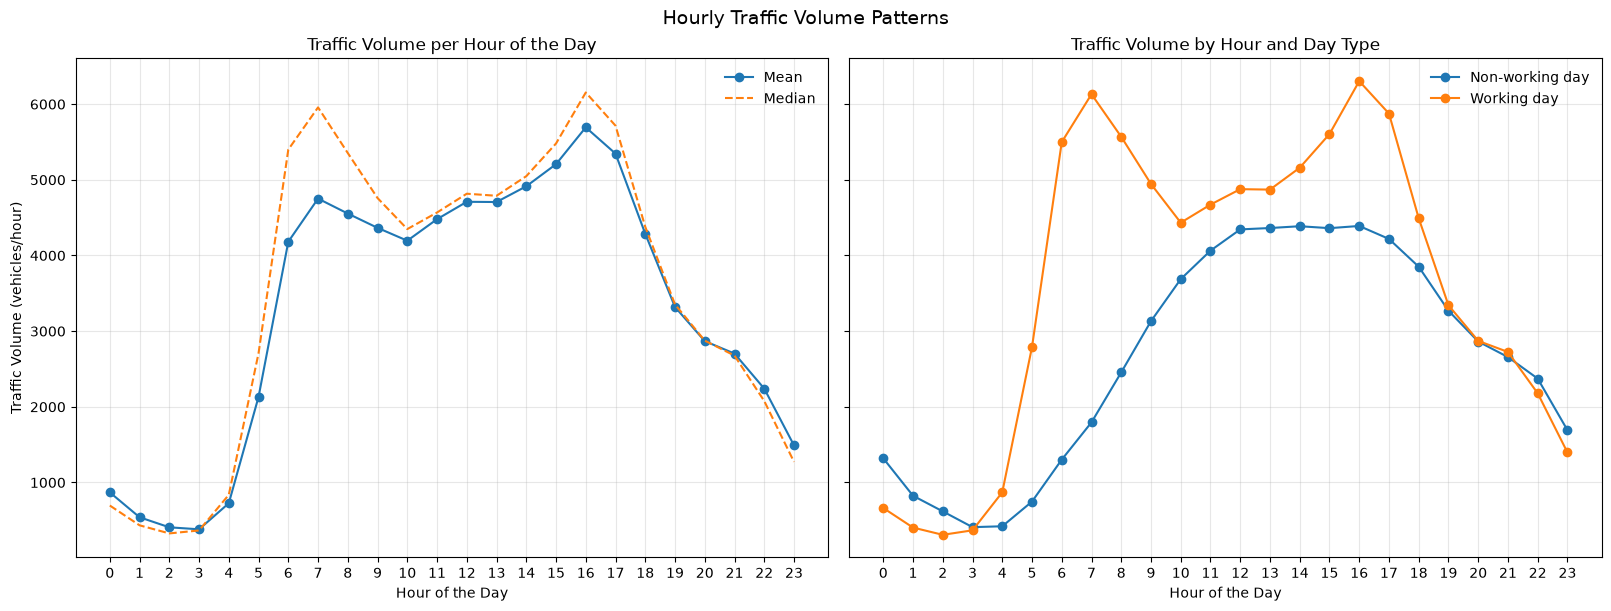

In [42]:
# Analyze traffic volume by hour of the day and day type

# Overall hourly statistics
hourly_stats = (
    train_df
    .groupby("hr")["traffic_volume"]
    .agg(
        mean="mean",
        median="median",
    )
)

# Hourly statistics by working day
hour_working_stats = (
    train_df
    .groupby(["hr", "workingday"])["traffic_volume"]
    .agg(
        mean="mean",
    )
)

day_types = {
    0: "Non-working day",
    1: "Working day",
}

colors = {
    0: "tab:blue",
    1: "tab:orange",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    constrained_layout=True,
)


# Plot 1: Overall behavior
axes[0].plot(
    hourly_stats.index,
    hourly_stats["mean"],
    marker="o",
    label="Mean",
)

axes[0].plot(
    hourly_stats.index,
    hourly_stats["median"],
    linestyle="--",
    label="Median",
)

axes[0].set_xlabel("Hour of the Day")
axes[0].set_ylabel("Traffic Volume (vehicles/hour)")
axes[0].set_title("Traffic Volume per Hour of the Day")
axes[0].set_xticks(range(24))
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=False)

# Plot 2: Behavior by day type
for day_type, label in day_types.items():
    stats = hour_working_stats.xs(
        day_type,
        level="workingday",
    )

    axes[1].plot(
        stats.index,
        stats["mean"],
        color=colors[day_type],
        marker="o",
        label=label,
    )

axes[1].set_xlabel("Hour of the Day")
axes[1].set_title("Traffic Volume by Hour and Day Type")
axes[1].set_xticks(range(24))
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=False)

fig.suptitle(
    "Hourly Traffic Volume Patterns",
    fontsize=14,
)

plt.show()

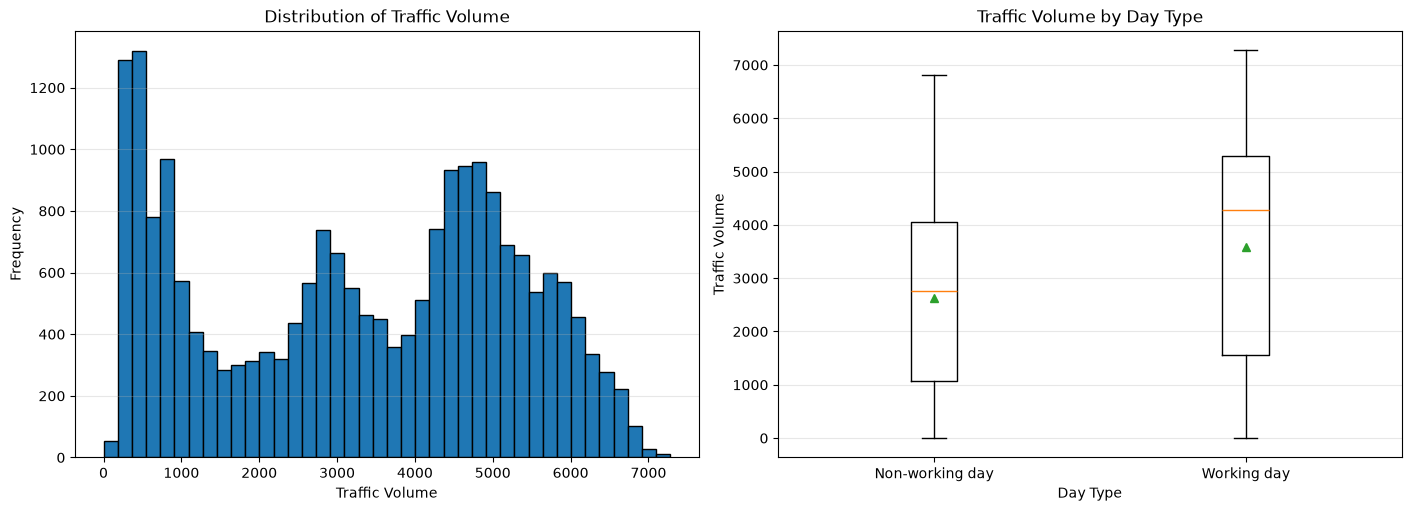

In [43]:
# Visualize the distribution of traffic volume and its relationship with the working day feature

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].hist(train_df["traffic_volume"], bins=40, edgecolor="black")
axes[0].set_title("Distribution of Traffic Volume")
axes[0].set_xlabel("Traffic Volume")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)

traffic_by_day_type = [
    train_df.loc[train_df["workingday"] == 0, "traffic_volume"],
    train_df.loc[train_df["workingday"] == 1, "traffic_volume"],
]

axes[1].boxplot(traffic_by_day_type, showmeans=True)
axes[1].set_title("Traffic Volume by Day Type")
axes[1].set_xlabel("Day Type")
axes[1].set_ylabel("Traffic Volume")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Non-working day", "Working day"])
axes[1].grid(axis="y", alpha=0.3)

plt.show()

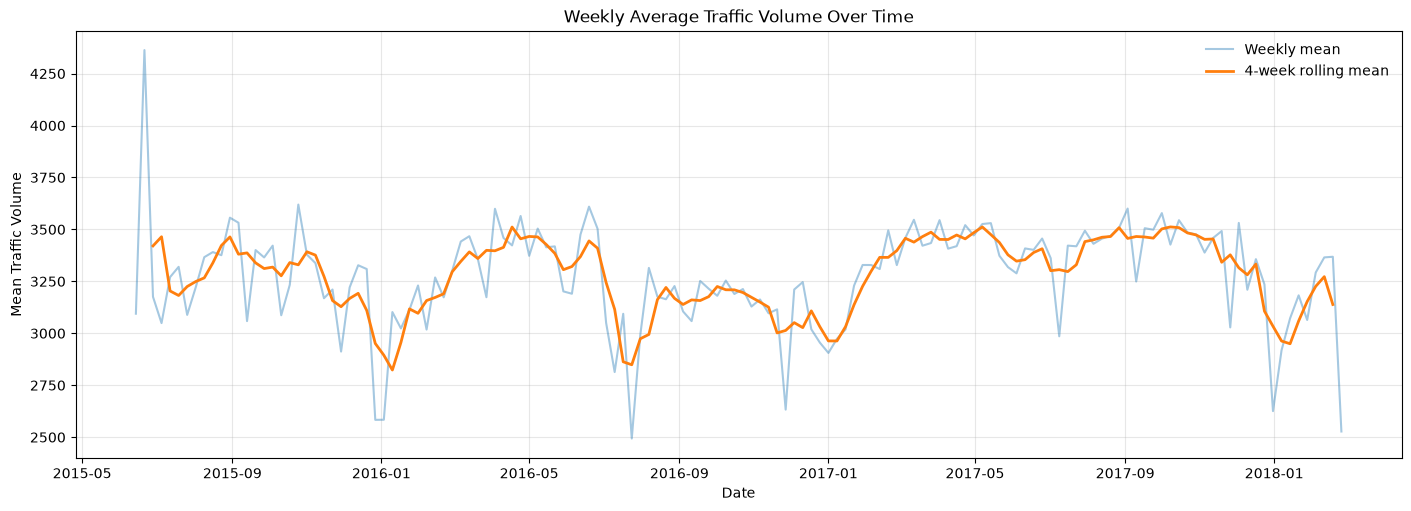

Hours in the training period: 23619 expected, 21341 present, 1682 gaps in the record
Overall mean traffic volume: 3278
Mean traffic volume per year (0 = 2015, 3 = 2018):


,mean_traffic_volume,first_date,last_date
yr,,,
0,3258.0,2015-06-11,2015-12-31
1,3194.0,2016-01-01,2016-12-31
2,3377.0,2017-01-01,2017-12-31
3,3168.0,2018-01-01,2018-02-19


Mean traffic volume per month:


mnth,1,2,3,4,5,6,7,8,9,10,11,12
traffic_volume,3091.0,3292.0,3464.0,3445.0,3371.0,3449.0,3115.0,3368.0,3329.0,3315.0,3177.0,3096.0


In [44]:
# Visualize the weekly average traffic volume over time (time series analysis)

weekly_traffic = (
    train_df
    .set_index("date")
    ["traffic_volume"]
    .resample("W")
    .mean()
)

weekly_rolling = weekly_traffic.rolling(
    window=4,
    center=True
).mean()

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

ax.plot(
    weekly_traffic.index,
    weekly_traffic.values,
    alpha=0.4,
    label="Weekly mean",
)

ax.plot(
    weekly_rolling.index,
    weekly_rolling.values,
    linewidth=2,
    label="4-week rolling mean",
)

ax.set_xlabel("Date")
ax.set_ylabel("Mean Traffic Volume")
ax.set_title("Weekly Average Traffic Volume Over Time")
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.show()

# Hours absent from the record: the timestamps are complete hours between the first
# and the last observation, so the gaps are the hours that were never reported
timestamps = train_df["date"] + pd.to_timedelta(train_df["hr"], unit="h")
expected_hours = int((timestamps.max() - timestamps.min()) / pd.Timedelta(hours=1)) + 1
print("Hours in the training period: {} expected, {} present, {} gaps in the record".format(
    expected_hours, len(train_df), int((timestamps.diff() > pd.Timedelta(hours=1)).sum())
))

# Mean traffic volume per year and per month, to separate a trend from the seasonal pattern
print("Overall mean traffic volume: {:.0f}".format(train_df["traffic_volume"].mean()))

print("Mean traffic volume per year (0 = 2015, 3 = 2018):")
display(
    train_df
    .groupby("yr")
    .agg(
        mean_traffic_volume=("traffic_volume", "mean"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .round({"mean_traffic_volume": 0})
)

print("Mean traffic volume per month:")
display(train_df.groupby("mnth")["traffic_volume"].mean().round(0).to_frame().T)

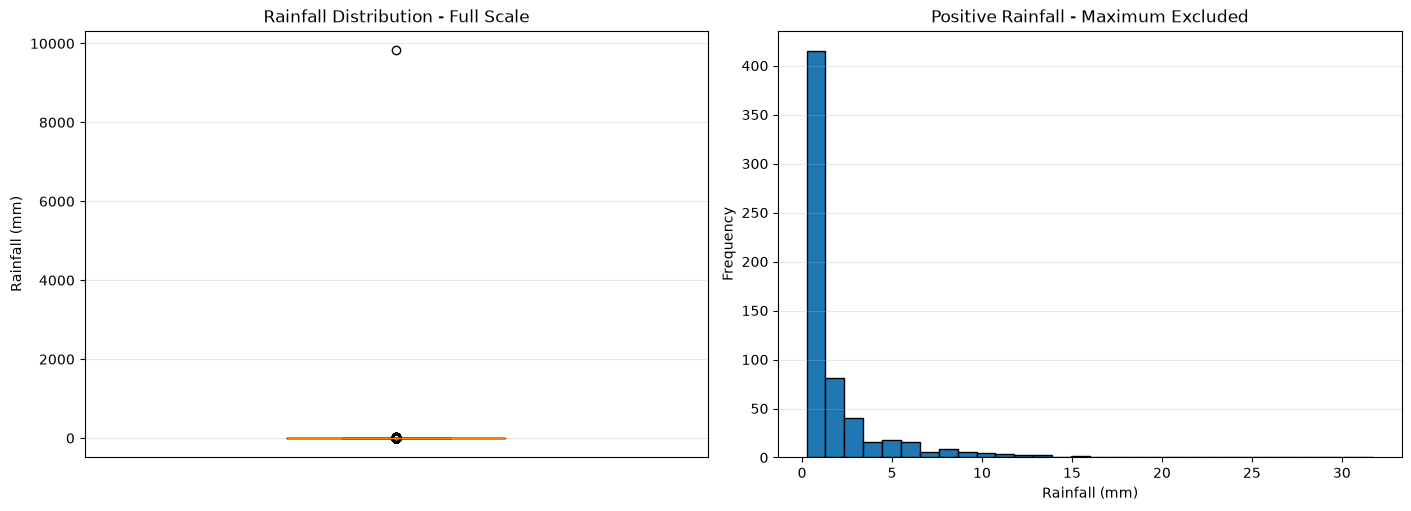

In [45]:
# Analyze the distribution of rainfall and its relationship with traffic volume

rain = train_df["rain_1h"]
extreme_rain_idx = rain.idxmax()
rain_without_extreme = rain.drop(index=extreme_rain_idx)
positive_rain_without_extreme = rain_without_extreme[rain_without_extreme > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].boxplot(rain, widths=0.35)
axes[0].set_title("Rainfall Distribution - Full Scale")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].set_xticks([])
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(positive_rain_without_extreme, bins=30, edgecolor="black")
axes[1].set_title("Positive Rainfall - Maximum Excluded")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.3)

plt.show()

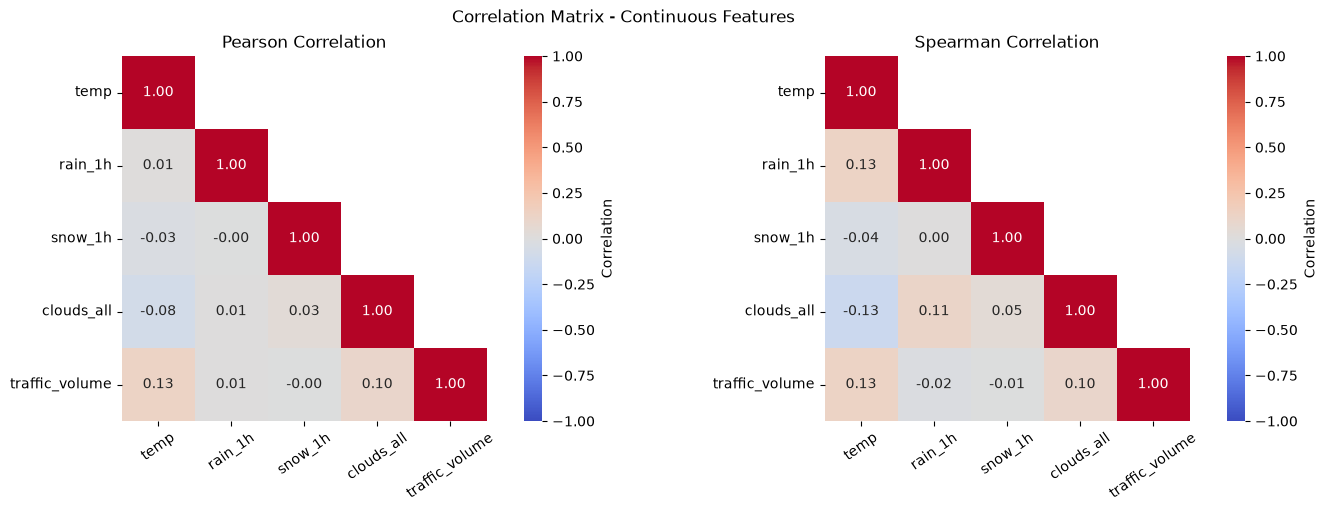

Hours with rain_1h above zero: 633 of 21341 (2.97%)
Hours with snow_1h above zero: 31 of 21341 (0.15%)


In [46]:
# Analyze the correlation between continuous features and traffic volume

continuous_cols = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "traffic_volume"
]

correlations = {
    "Pearson": train_df[continuous_cols].corr(method="pearson"),
    "Spearman": train_df[continuous_cols].corr(method="spearman"),
}
mask = np.triu(np.ones_like(correlations["Pearson"], dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (method, corr) in zip(axes, correlations.items()):
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=ax,
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title(f"{method} Correlation")
    ax.tick_params(axis="x", labelrotation=35)
    ax.tick_params(axis="y", labelrotation=0)

fig.suptitle("Correlation Matrix - Continuous Features")
plt.show()

# Share of hours with any precipitation, which limits how much these features can explain
for column in ["rain_1h", "snow_1h"]:
    positive = train_df[column] > 0
    print(f"Hours with {column} above zero: {positive.sum()} of {len(train_df)} ({100 * positive.mean():.2f}%)")

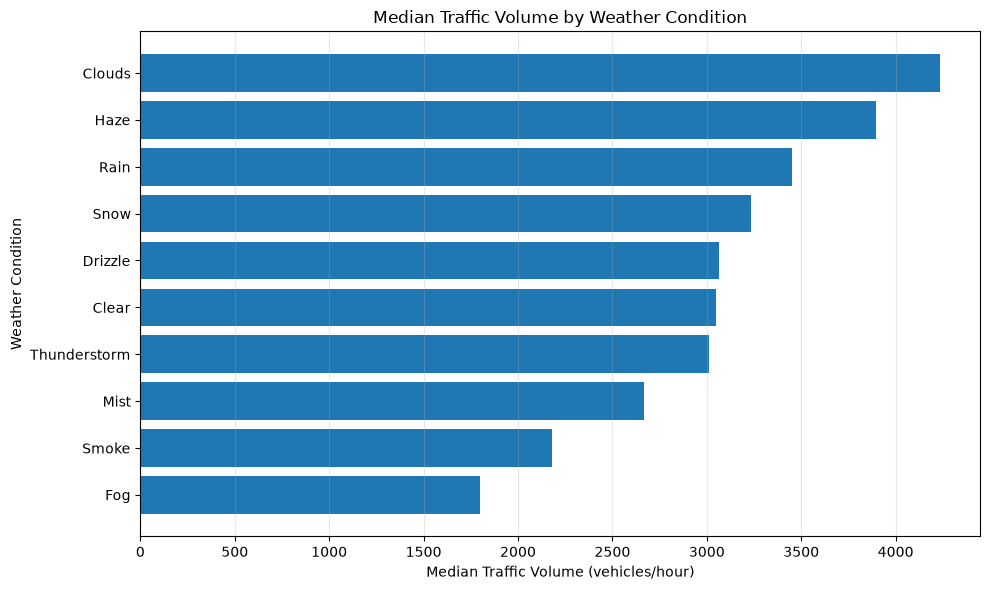

In [47]:
# Analyze the relationship between traffic volume and weather conditions

weather_stats = (
    train_df
    .groupby("weather")["traffic_volume"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    weather_stats.index,
    weather_stats.values,
)

plt.xlabel("Median Traffic Volume (vehicles/hour)")
plt.ylabel("Weather Condition")
plt.title("Median Traffic Volume by Weather Condition")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

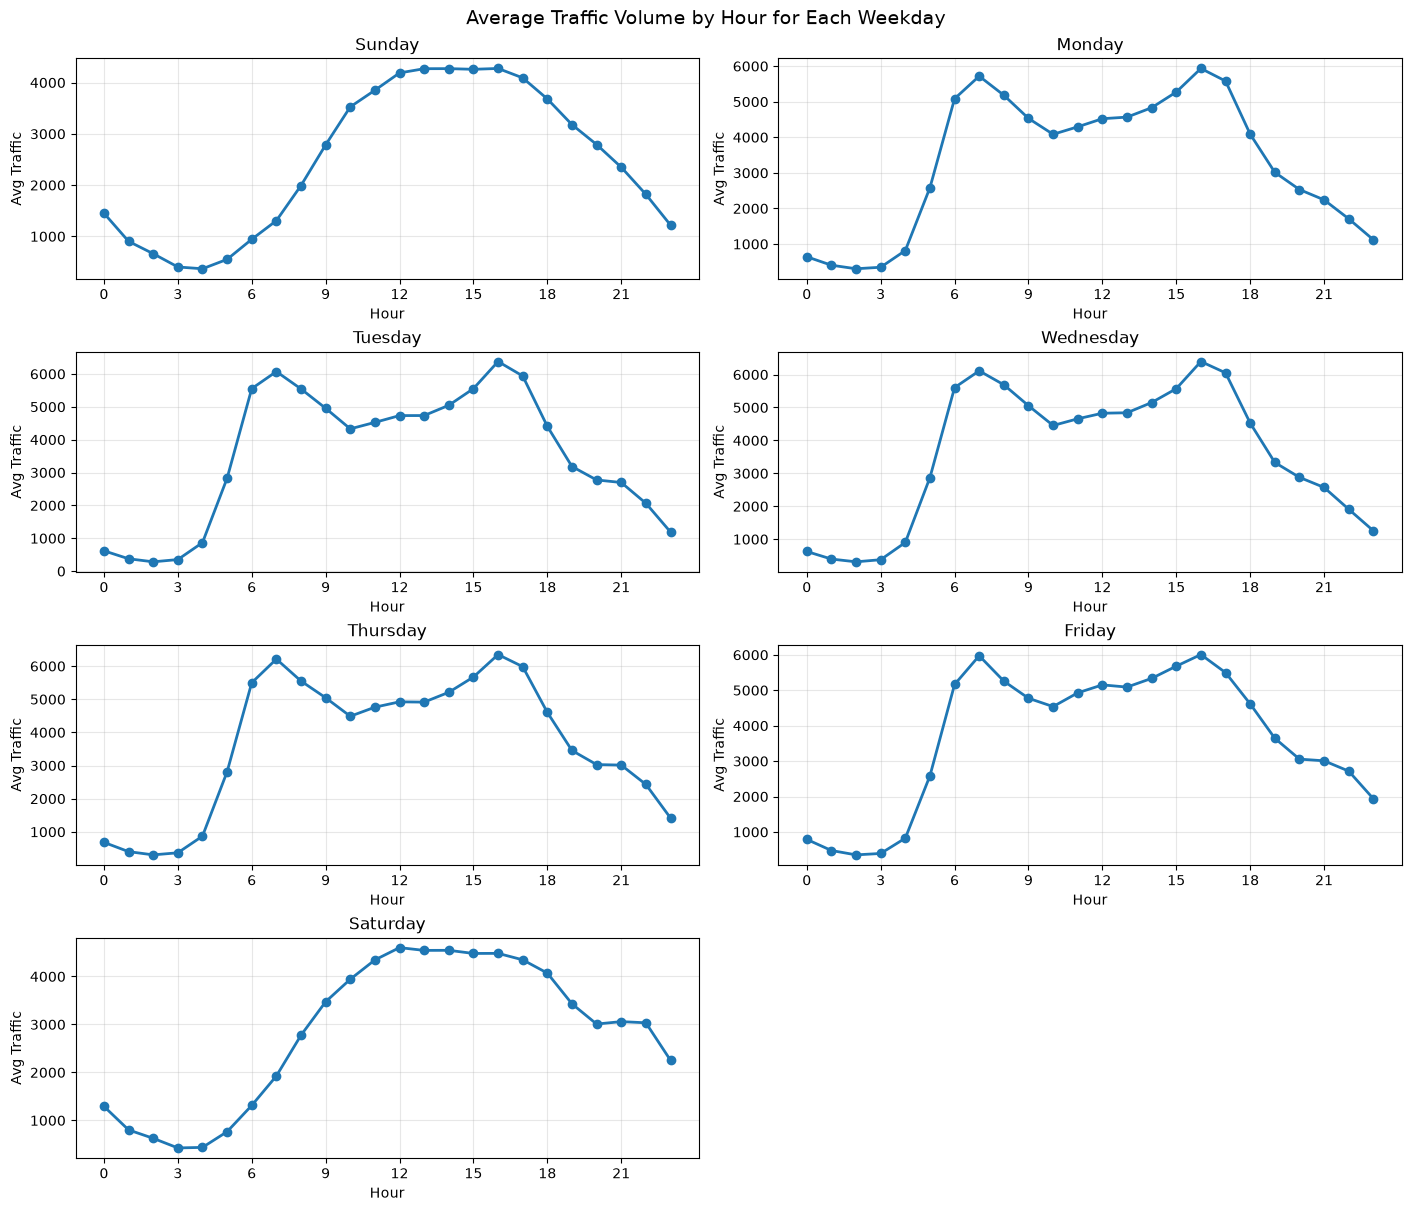

In [48]:
weekday_hour = (
    train_df
    .groupby(["weekday", "hr"])["traffic_volume"]
    .mean()
    .reset_index()
)

weekday_names = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
}

fig, axes = plt.subplots(4, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

for i, weekday in enumerate(range(7)):
    day_data = weekday_hour[weekday_hour["weekday"] == weekday]

    axes[i].plot(
        day_data["hr"],
        day_data["traffic_volume"],
        marker="o",
        linewidth=2,
    )
    axes[i].set_title(weekday_names[weekday])
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].grid(alpha=0.3)
    axes[i].set_xlabel("Hour")
    axes[i].set_ylabel("Avg Traffic")

# Remove o último subplot vazio
fig.delaxes(axes[7])

fig.suptitle("Average Traffic Volume by Hour for Each Weekday", fontsize=14)
plt.show()

> **Question:**
> 
> How did the visualization help in understanding the data?
> Which questions were answered and what hypothesis are left to be tested? 
> 
> Have you decided to remove some feature from the dataset? Why?

**Answer**

As visualizações permitiram identificar padrões que não eram evidentes apenas pelas estatísticas descritivas, principalmente em relação à estrutura temporal do problema, às interações entre variáveis e à presença de dados anômalos.

O gráfico de "traffic_volume" em função da hora do dia evidencia uma variação expressiva do volume de tráfego ao longo das 24 horas. Durante a madrugada, o fluxo permanece em níveis reduzidos, aumentando rapidamente nas primeiras horas da manhã e mantendo-se elevado ao longo de boa parte do dia, com picos no final da tarde. Observa-se também que, em determinados horários, a diferença entre a média e a mediana se torna mais evidente, indicando possíveis assimetrias na distribuição do volume de tráfego. Esses padrões fornecem indícios de uma associação relevante e não linear entre "hr" e a variável-alvo.

Ao separar por "workingday", observa-se que os dias úteis apresentam picos pela manhã e no final da tarde, enquanto dias não úteis possuem crescimento mais gradual e um padrão mais estável durante o dia, sugerindo uma interação entre "hr" e "workingday". A análise por "weekday" também reforça que os dias úteis apresentam perfis semelhantes entre si enquanto finais de semana têm comportamento distinto, indicando que a feature "weekday" pode conter informação adicional além dos padrões expressos por "workingday".

Além disso, como nosso objetivo é predizer o target a partir de informações temporais, analisamos a evolução da média semanal de "traffic_volume". A série não apresenta uma tendência global clara de crescimento ou queda, mas exibe oscilações de médio prazo relativamente recorrentes, com períodos de aumento gradual seguidos por quedas mais acentuadas. Esse comportamento sugere a presença de sazonalidade anual: janeiro é o mês de menor volume médio no treino (3091 veículos/hora, contra 3278 da média geral). Entre anos, por outro lado, não há tendência: as médias anuais são de 3258, 3194, 3377 e 3168 para 2015 a 2018, lembrando que 2015 começa em junho e 2018 contém apenas janeiro e fevereiro. Por isso tratamos "yr" como variável categórica, o que permite ao modelo absorver diferenças de nível entre os anos sem impor uma relação linear que os dados não sustentam. Vale notar que o registro não é contínuo: das 23619 horas do período de treinamento, 21341 estão presentes, com 1682 lacunas. Como os modelos não utilizam o volume das horas anteriores, essas lacunas não exigem imputação.

Já a análise de rain_1h confirmou um valor extremo de aproximadamente 9831.3 mm, muito acima do restante da distribuição. A variável "snow_1h", por sua vez, é positiva em apenas 31 das 21341 horas do treinamento (0.15%), de modo que praticamente não carrega informação e foi removida do conjunto de features. As categorias de "weather" também apresentam diferenças no volume mediano de tráfego, mas devemos interpretar essas diferenças apenas como associações marginais, já que podem estar relacionadas a horário, estação ou outras variáveis temporais.

No momento, "date" pode deixar de ser usada diretamente como entrada do modelo após a extração das informações temporais relevantes, as colunas "weekday", "workingday" e as demais variáveis meteorológicas devem ser mantidas, por apresentarem associações iniciais interessantes. Por outro lado, removemos "instant", que é apenas um identificador, "season", que é determinada por "mnth", e "weather_desc", que apenas subdivide "weather" em 34 categorias, optando pela representação mais agregada. Permanecem como hipóteses a serem testadas a importância das interações temporais e a possível sazonalidade indicada pela série temporal.

----
### **Preprocessing**
(1.0 point) Now that you have a deeper insight about the problem, let's preprocess
the raw data with the necessary transformations and turn the data into an array,
ready to be fed into a model.

Create a function `preprocess_data` and make all required transformation, the
output must be a tuple (X, y) of numpy arrays, where X has shape (n_samples, n_features)
and y is a column array of shape (n_samples,).

Note that the distributions on the features in the test set may not coincide
with the ones in the train set, your preprocessing must take that into account
without peeking at test samples.

In [49]:
# Preprocessing settings

# snow_1h is left out: it is positive in only 31 of the 21341 training hours,
# so it carries almost no information and its polynomial terms are degenerate
CONTINUOUS_FEATURES = [
    "temp",
    "rain_1h",
    "clouds_all",
]

# yr is categorical: the yearly means show no trend, so a single slope over the
# year index would impose a linear relationship the data does not support
CATEGORICAL_FEATURES = [
    "yr",
    "mnth",
    "hr",
    "weekday",
    "weather",
]

BINARY_FEATURES = [
    "holiday",
    "workingday",
]

In [50]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(df: pd.DataFrame, reference_df: pd.DataFrame) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Preprocesses the dataset and returns (X, y).
    
    Parameters:
        df (pd.DataFrame): The input DataFrame with the dataset to be transformed.
        reference_df (pd.DataFrame): Dataset used to estimate preprocessing parameters.
    """

    data = df.copy()
    reference = reference_df.copy()
    
    # Target
    y = data["traffic_volume"].to_numpy(dtype=np.float64)
    
    # Treat rain_1h anomalous observation
    valid_reference_rain = reference.loc[reference["rain_1h"] < 300, "rain_1h"]
    rain_cap = valid_reference_rain.max()

    data["rain_1h"] = data["rain_1h"].clip(upper=rain_cap)
    reference["rain_1h"] = reference["rain_1h"].clip(upper=rain_cap)
    
    # Preprocess continuous features
    reference_medians = reference[CONTINUOUS_FEATURES].median()
    continuous = data[CONTINUOUS_FEATURES].fillna(reference_medians)
    reference_continuous = reference[CONTINUOUS_FEATURES].fillna(reference_medians)

    scaler = StandardScaler()
    scaler.fit(reference_continuous)

    continuous = pd.DataFrame(
        scaler.transform(continuous),
        columns=CONTINUOUS_FEATURES,
        index=data.index,
    )
    
    # Preprocess binary features
    binary = data[BINARY_FEATURES].copy()

    for column in BINARY_FEATURES:
        reference_mode = reference[column].mode().iloc[0]

        binary[column] = (
            binary[column]
            .fillna(reference_mode)
            .astype(float)
        )
    
    # Preprocess categorical features
    categorical = pd.DataFrame(index=data.index)

    for column in CATEGORICAL_FEATURES:
        categories = sorted(
            reference[column]
            .dropna()
            .unique()
            .tolist()
        )

        categorical[column] = pd.Categorical(
            data[column],
            categories=categories,
        )

    categorical = pd.get_dummies(
        categorical,
        columns=CATEGORICAL_FEATURES,
        drop_first=True,
        dtype=float,
    )
    
    # Create interaction between hr and workingday
    # This is based on the analysis of traffic volume by hour and day type
    # which showed different patterns for working and non-working days.
    hour_columns = [
        column for column in categorical.columns
        if column.startswith("hr_")
    ]

    hour_workingday = (
        categorical[hour_columns]
        .mul(binary["workingday"], axis=0)
        .add_prefix("workingday_x_")
    )

    # Concatenate all features
    # workingday is used in the interactions, but its standalone column is
    # redundant with the weekday indicators and holiday.
    X = pd.concat(
        [
            continuous,
            binary.drop(columns=["workingday"]),
            categorical,
            hour_workingday,
        ],
        axis=1,
    )

    X = X.to_numpy(dtype=np.float64)
    
    return X, y

---

## **Linear Regression**

Linear regression is a simple model that assumes a linear relationship between
the observed features and the target.
Specifically, given an observation $(x_1, x_2, \dots, x_n)$, we assume there exist
a set of weights $\beta_0, \beta_1, \beta_2, \dots, \beta_n$ such that

$$y \approx \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n.$$

Each weight $\beta_i$ measures the marginal contribution of $x_i$ to the
prediction while keeping other variables fixed.
The model assumes additive effects, meaning the influence of multiple variables
is the sum of their individual contributions unless interaction terms are
explicitly included.

For example, if raining decreases the traffic volume, but the morning rush hour
increases it, a rainy rush hour contribution is no different than the contribution
of rainy plus the contribution of the rush hour.

We can estimate the weights $\beta_i$ by measuring a discrepancy score between
predicted values $\hat{y}$ obtained with some weight $\beta$ and the ground-truth
value $y$, and minimizing this score.

A natural way to achieve this is by defining a distance between targets that is
differentiable. However, choosing a distance that is statistical relevant is not
trivial. Instead, we could measure what is the probability that, when given
a sample $x$ and a current weight $\beta$, the ground-truth $y$ is observed, *i.e.*

$$p(y \mid x, \beta).$$

This measures what is the probability of the ground-truth given that the model
with weights $\beta$ is the true estimator.

If we tweak the weights $\beta$ so that the probability of all ground-truths is
maximized, we obtain a well-fit model.
This is achieved by the likelihood function, under the assumption of independent
samples in the dataset.

$$\mathcal{L}(\beta) = \prod_{i=1}^n p(y^i \mid x^i, \beta).$$

Indicating that an estimator $\beta$ is only good if the ground-truth probabilities
are high across all the samples. As this criteria can be very small due to the
multiplication of small quantities, a common trick is to use the log likelihood
function instead, using the log properties,

$$\log \mathcal{L}(\beta) = \sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
and then minimizing $-\log \mathcal{L}(\beta)$.

This method is called Maximum Likelihood Estimation (MLE) and it is a very commonly
used estimator in Machine Learning, as we are going to see.

### **Gaussian assumption**
We cannot directly measure $p(y \mid x, \beta)$ at the moment, as we do not have
a probability distribution that links $y$ with $x$ and $\beta$ yet, but a
deterministic relationship (linear).

To introduce this probabilistic aspect, we can suppose that the approximation
between the ground-truth $y$ and the linear term $\hat{y} = \beta_0 + \beta_1 x_1 + \dots$
is only wrong by an unpredictable "error" $\epsilon$, also called a *residual*.
A common way of introducing this error is by supposing that $\epsilon$ comes from
a zero-centered normal (or Gaussian) distribution,
*i.e.* $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

The relationship between $y$, $x$ and $\beta$ are now intermediated by $\epsilon$,

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon.$$

This makes $y$ to be a random variable centered at our linear predicition, deviated
by a random quantity, with fixed standard deviation $\sigma$ (homoscedastic).
This assumption is called **Gaussian assumption**, and has interesting properties
that intersect with the Ordinary Least Squares method, including the criterion.

With this assumption, we can measure $p(y \mid x, \beta)$ directly using the
Normal probability distribution function

$$p(y \mid x, \beta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(- \frac{(y - x^T\beta)^2}{2\sigma^2}\right),$$

$$\log p(y \mid x, \beta) =  - \frac{(y - x^T\beta)^2}{2\sigma^2} - \log(\sqrt{2\pi\sigma^2}).$$

Thus, minimizing $-\log \mathcal{L}(\beta)$, yield to

$$-\log \mathcal{L}(\beta) \propto \sum_{i=1}^n (y^i - {x^i}^T\beta)^2 = \sum_{i=1}^n (y^i - \hat{y}^i)^2 $$

Which is equivalent to the Mean Squared Error (MSE) criterion.

### **Implementation**

(0.5 points) Under the statistical lens of Linear Regression, we have also
derived the same loss function as ordinary least squares method. Now it's time to
implement the `fit` method using **gradient descent** without using any machine
learning library.


Also, complete the following metric functions with their implementations and run
your model for different learning rates

In [51]:
def mse(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    # Calculate the Mean Squared Error
    return np.mean((y_true - y_pred) ** 2)


def r2_score(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    # Calculate the mean of the true values
    y_true_mean = np.mean(y_true)
    
    # Calculate the residual sum of squares (SS_res)
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Calculate the total sum of squares (SS_tot)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)
    
    # Guard
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    
    return 1 - (ss_res / ss_tot)


def mae(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    # Calculate the Mean Absolute Error
    return np.mean(np.abs(y_true - y_pred))


class LinearRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None

    def fit(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        n_samples, n_features = X.shape
        
        # Initialize parameters
        weights = np.zeros(n_features)
        bias = 0.0
        
        # Gradient descent
        for _ in range(self.n_iterations):
            # Forward
            y_pred = np.dot(X, weights) + bias
            
            # Error
            error = y - y_pred
            
            # Gradient calculation
            dw = (-2 / n_samples) * np.dot(X.T, error)
            db = (-2 / n_samples) * np.sum(error)
            
            # Gradient update
            weights -= self.learning_rate * dw
            bias -= self.learning_rate * db
            
        
        # Save the learned parameters
        self.weights = weights
        self.bias = bias
            
    
    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"

        return np.dot(X, self.weights) + self.bias

In [52]:
def plot_results(lrs: list[float], performances: dict[str, list[float]]) -> None:
    n_metrics = len(performances)

    fig, ax = plt.subplots(figsize=(5 * n_metrics, 5), ncols=n_metrics)

    for i, (metric_name, metric_values) in enumerate(performances.items()):
        ax[i].plot(lrs, metric_values, marker="o")

        # A diverged run has infinite or NaN metrics, which matplotlib silently
        # drops. They are marked with a red line so the divergence stays visible.
        for lr, value in zip(lrs, metric_values):
            if not np.isfinite(value):
                ax[i].axvline(lr, color="red", linestyle="--", alpha=0.6, label="Diverged")
        if not np.all(np.isfinite(metric_values)):
            ax[i].legend()
        ax[i].set_xlabel("Learning Rate")
        ax[i].set_title(metric_name)
        ax[i].grid()
    
        ax[i].set_xscale("log")

    plt.tight_layout()
    plt.show()

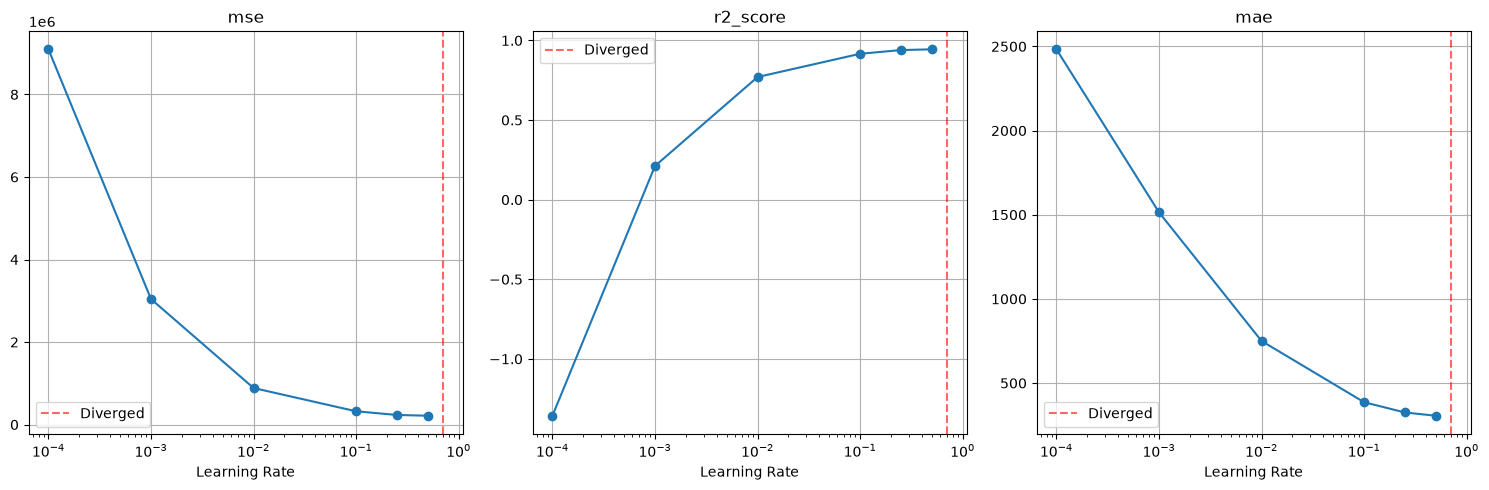

In [53]:
X, y = preprocess_data(train_df, reference_df=train_df)

# You can experiment with a pre-defined set of learning rates or
# with a range of learning rates (e.g. logarithmically spaced)
lrs = [0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.7]

performances = {
    "mse": [],
    "r2_score": [],
    "mae": [],
}

for lr in lrs:
    model = LinearRegression(learning_rate=lr, n_iterations=1000)

    # The largest learning rates make gradient descent diverge until the weights
    # overflow, and numpy warns at every operation that follows. The divergence
    # itself is part of the experiment and shows up in the metrics, so the
    # warnings are silenced here.
    with np.errstate(over="ignore", invalid="ignore"):
        model.fit(X, y)
        y_pred = model.predict(X)

    with np.errstate(over="ignore", invalid="ignore"):
        mse_score = mse(y, y_pred)
        r2 = r2_score(y, y_pred)
        mae_score = mae(y, y_pred)

    # A diverged run has no meaningful metrics: the MSE overflows to infinity while
    # the MAE can still be a huge finite number, so all of them are recorded as NaN
    if not np.isfinite(mse_score):
        mse_score, r2, mae_score = np.nan, np.nan, np.nan

    performances["mse"].append(mse_score)
    performances["r2_score"].append(r2)
    performances["mae"].append(mae_score)

plot_results(lrs, performances)

In [54]:
# Summarize the numerical results and compare the errors with the target scale
results = pd.DataFrame({
    "learning_rate": lrs,
    "mse": performances["mse"],
    "rmse": np.sqrt(performances["mse"]),
    "mae": performances["mae"],
    "r2_score": performances["r2_score"],
})

target_mean = np.mean(y)
target_std = np.std(y)
results["mae_pct_of_target_mean"] = 100 * results["mae"] / target_mean
results["rmse_pct_of_target_std"] = 100 * results["rmse"] / target_std

print(
    f"Target scale: mean={target_mean:.2f}, standard deviation={target_std:.2f}, "
    f"range=[{y.min():.0f}, {y.max():.0f}]"
)
print("Hours with traffic_volume equal to zero:", int((y == 0).sum()))
print("NaN means the run diverged")
display(results.round(4))

Target scale: mean=3277.75, standard deviation=1964.22, range=[0, 7280]
Hours with traffic_volume equal to zero: 2
NaN means the run diverged


,learning_rate,mse,rmse,mae,r2_score,mae_pct_of_target_mean,rmse_pct_of_target_std
0,0.0001,9.093592e+06,3015.5583,2482.8043,-1.3570,75.7472,153.5242
1,0.0010,3.041657e+06,1744.0346,1514.4109,0.2116,46.2028,88.7900
2,0.0100,8.860846e+05,941.3207,749.9863,0.7703,22.8811,47.9233
3,0.1000,3.224238e+05,567.8238,386.2363,0.9164,11.7836,28.9083
4,0.2500,2.331220e+05,482.8271,325.3097,0.9396,9.9248,24.5811
5,0.5000,2.146284e+05,463.2801,305.9902,0.9444,9.3354,23.5859
6,0.7000,NaN,NaN,NaN,NaN,NaN,NaN


> **Question:**
>
> How did the model perform for different learning rates?
> What happened when the learning rate was too small or too large?
>
> Interpret the metric values obtained.
Is the prediction error small relative to the scale of the target variable?
>
> Propose at least one hypothesis explaining the observed error.

**Answer:**

O desempenho do modelo variou significativamente com o learning rate. Para valores muito pequenos, como 0.0001 e 0.001, o erro permaneceu elevado após 1000 iterações, indicando convergência muito lenta. À medida que o learning rate aumentou, o modelo convergiu mais rapidamente para uma solução melhor. Os resultados melhoraram progressivamente até lr = 0.5, que apresentou o melhor desempenho entre os valores testados, conforme demonstrado na tabela acima.

Entretanto, com lr = 0.7, o gradiente descendente divergiu: o erro cresceu sem limites até exceder a representação numérica, e por isso as métricas aparecem como NaN na tabela. Isso indica que o learning rate se tornou grande demais, fazendo com que cada atualização do gradiente ultrapassasse a região ótima da função de custo por uma margem maior que a anterior, em vez de convergir.

Considerando o melhor modelo (lr = 0.5), o $R^2 \approx$ 0.94 indica que cerca de 94% da variabilidade do traffic_volume no conjunto de treinamento é explicada pelo modelo. O MAE $\approx$ 306 veículos/hora corresponde a aproximadamente 9.3% do volume médio de tráfego, enquanto o RMSE $\approx$ 463 representa cerca de 23.6% do desvio padrão do target. Portanto, o erro pode ser considerado relativamente pequeno em relação à escala geral do problema, embora ainda possa ser relevante em períodos de baixo volume.

Uma possível explicação para o erro residual é que a regressão linear consegue assumir apenas alguns efeitos sobre as features, não conseguindo capturar certos padrões. Na análise exploratória desenvolvida no início do notebook, observamos a existência de relações temporais mais complexas, como relações sazonais, que podem não estar sendo completamente capturadas pelo modelo linear atual. Dessa forma, parte da variação do tráfego estaria sem explicação e causando o erro observado.

---
### **Visualizing Predictions**

(1.0 points) Numerical metrics summarize model quality, but visual diagnostics reveal structural problems that scalar measures may hide. Two standard visual tools are the predicted vs. observed plot and the Q–Q plot of residuals.

Choose a model from the previous session to analyse further here.

#### **Predicted vs. Observed Plot**

A direct way to evaluate prediction quality is to compare the predicted values with the true observations.
For each sample, plot the pair `(y, y_pred)`, the ideal predictor would have
perfectly match predictions, yielding all points in the line y = x in the graph.

However, this is often not the case, as prediction can go wrong.
This plot help us interpret points that are closer to the x=y line as better
predictions, and points further from this line as bad predictions.

If the overall shape of the points does not follow the line, we may have a
**systematic error**, indicating model misspecification.

By coloring each point by some other characteristic, we can also see if the error
is systematic with respect to that characteristic.
For example, the model mispredicts some seasons more than others.

You can explore more plots to get an insight on why and how is your model fit.

In [55]:
def pred_vs_true_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    _, ax = plt.subplots(figsize=(10, 6))

    ax.grid()
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', label='Ideal Fit')
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title("Predicted vs True Values")
    ax.legend()
    plt.show()

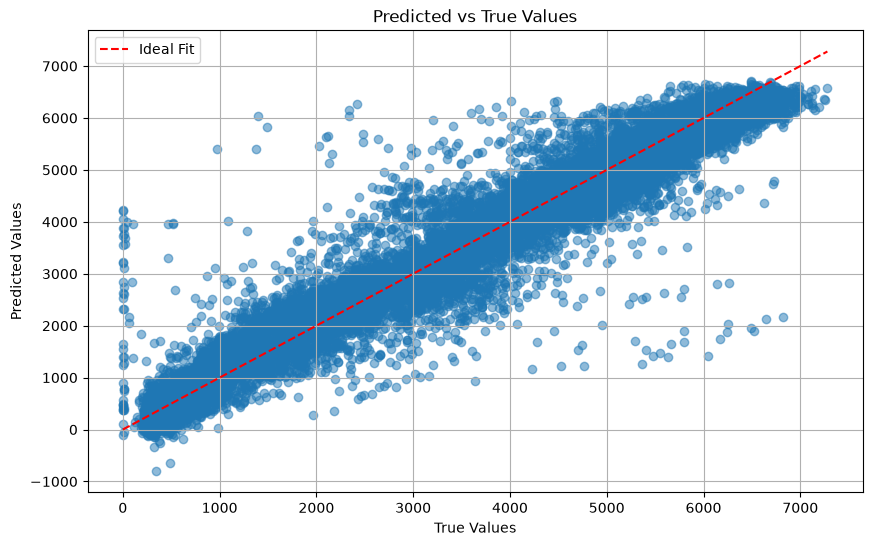

In [56]:
best_lr = 0.5 # Choose the best learning rate based on the previous graphs

best_linear_model = LinearRegression(learning_rate=best_lr, n_iterations=10000)
best_linear_model.fit(X, y)
y_pred = best_linear_model.predict(X)

pred_vs_true_plot(y, y_pred)

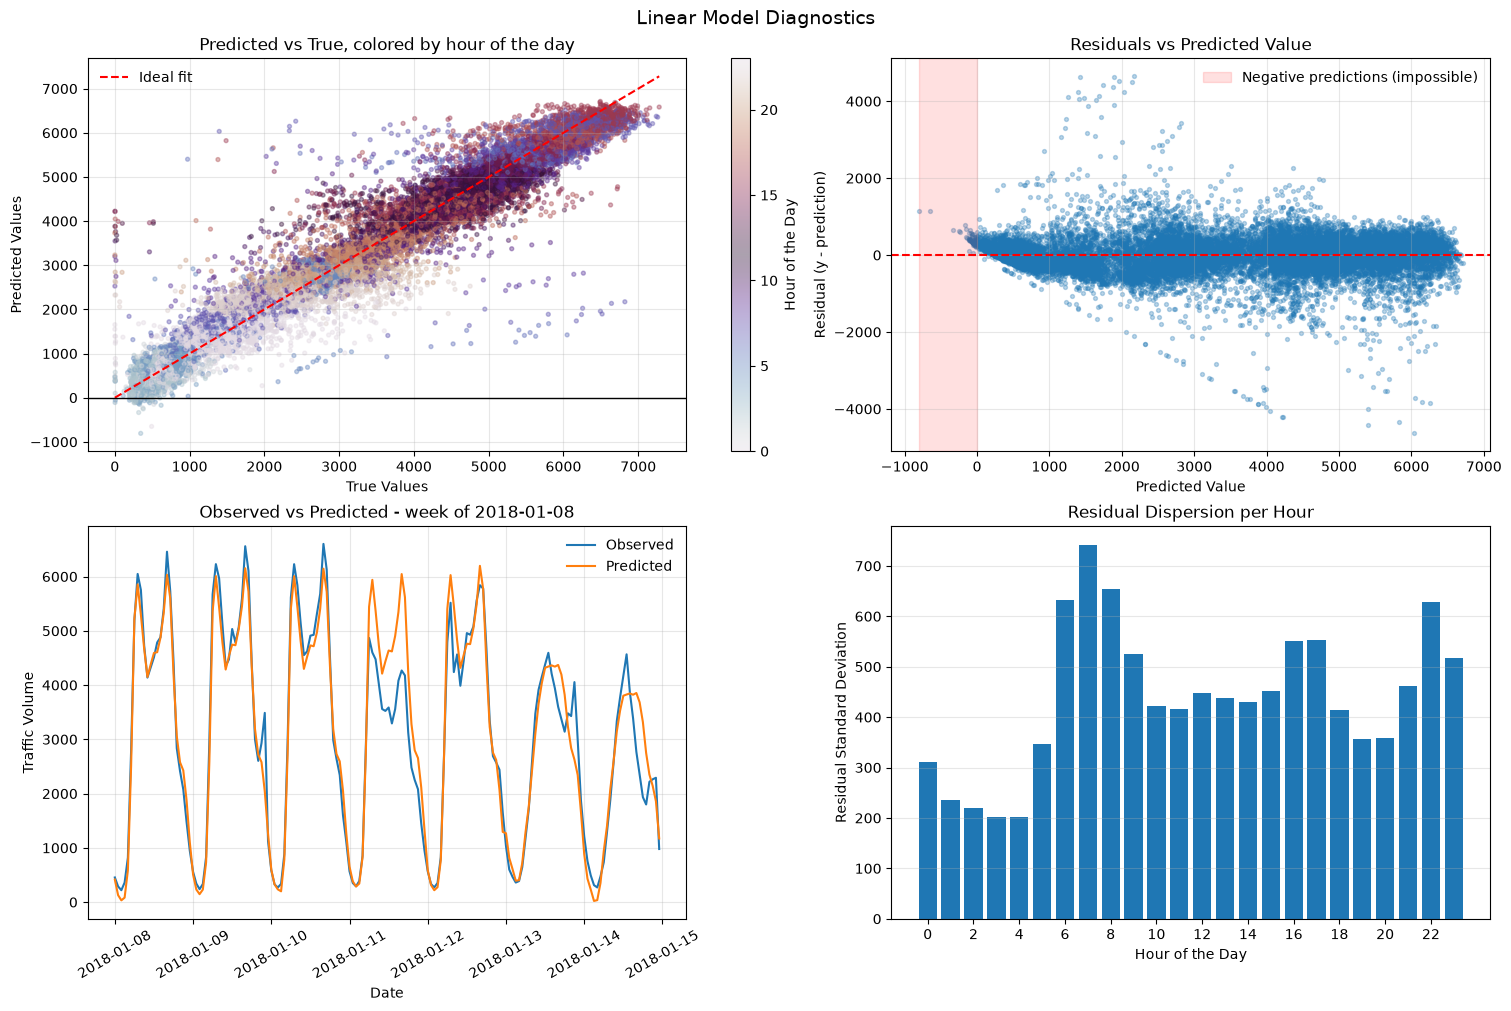

Negative predictions: 74 (0.35% of the training set)
Smallest prediction: -807.8 vehicles/hour
Hours in which the negative predictions occur: [0, 1, 2, 3, 4]

Mean traffic volume, and residual mean and dispersion, per hour (vehicles/hour):


,traffic_volume_mean,residual_mean,residual_std
hr,,,
0,869.3,4.3,310.2
1,540.5,-0.2,235.5
2,407.7,-0.2,220.3
3,381.2,-0.2,201.9
4,726.0,-0.2,201.2
5,2131.8,-0.2,346.9
6,4182.0,-0.2,633.3
7,4751.8,-0.2,741.9
8,4554.2,-0.2,654.8



Average residual per observed traffic level:


,count,mean
level,,
"(-0.001, 500.0]",2445,-72.3
"(500.0, 1500.0]",3375,-123.2
"(1500.0, 3000.0]",3555,-124.7
"(3000.0, 4500.0]",4423,-1.3
"(4500.0, 6000.0]",6104,98.2
"(6000.0, 7300.0]",1439,307.3


In [57]:
# Diagnostics for the best linear model: where the error is, and how it is structured

residuals = y - y_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# Plot 1: predicted vs observed, colored by the hour of the day, to check whether
# the deviation from the ideal line is associated with a specific time of the day.
# The colormap is a cyclic one, since the hour wraps around at midnight.
scatter = axes[0, 0].scatter(y, y_pred, c=train_df["hr"], cmap="twilight", alpha=0.4, s=8)

axes[0, 0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red",
    linestyle="--",
    label="Ideal fit",
)
axes[0, 0].axhline(0, color="black", linewidth=1)

axes[0, 0].set_xlabel("True Values")
axes[0, 0].set_ylabel("Predicted Values")
axes[0, 0].set_title("Predicted vs True, colored by hour of the day")
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=0.3)

fig.colorbar(scatter, ax=axes[0, 0], label="Hour of the Day")

# Plot 2: residuals against the predicted value, to inspect the homoscedasticity
# assumption. The shaded band marks predictions that are impossible for a count.
axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=8)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].axvspan(
    y_pred.min(),
    0,
    color="red",
    alpha=0.12,
    label="Negative predictions (impossible)",
)

axes[0, 1].set_xlabel("Predicted Value")
axes[0, 1].set_ylabel("Residual (y - prediction)")
axes[0, 1].set_title("Residuals vs Predicted Value")
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(alpha=0.3)

# Plot 3: observed and predicted series over one fully covered week of the training
# set, to see the shape of the fit along time instead of as a cloud
timestamp = train_df["date"] + pd.to_timedelta(train_df["hr"], unit="h")
week = ((timestamp >= "2018-01-08") & (timestamp < "2018-01-15")).to_numpy()

axes[1, 0].plot(timestamp[week], y[week], label="Observed", linewidth=1.5)
axes[1, 0].plot(timestamp[week], y_pred[week], label="Predicted", linewidth=1.5)

axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Traffic Volume")
axes[1, 0].set_title("Observed vs Predicted - week of 2018-01-08")
axes[1, 0].legend(frameon=False)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis="x", labelrotation=30)

# Plot 4: dispersion of the residuals per hour. The mean is not informative here
# (see the answer below), so we look at the standard deviation instead.
hourly_residuals = pd.DataFrame(
    {
        "hr": train_df["hr"].to_numpy(),
        "traffic_volume": y,
        "residual": residuals,
    }
)
hourly_spread = hourly_residuals.groupby("hr")["residual"].std()

axes[1, 1].bar(hourly_spread.index, hourly_spread.values)

axes[1, 1].set_xlabel("Hour of the Day")
axes[1, 1].set_ylabel("Residual Standard Deviation")
axes[1, 1].set_title("Residual Dispersion per Hour")
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle("Linear Model Diagnostics", fontsize=14)
plt.show()

# Numbers quoted in the discussion below
negative = y_pred < 0

print("Negative predictions: {} ({:.2f}% of the training set)".format(negative.sum(), 100 * negative.mean()))
print("Smallest prediction: {:.1f} vehicles/hour".format(y_pred.min()))
print("Hours in which the negative predictions occur:", sorted(train_df.loc[negative, "hr"].unique().tolist()))
print()

print("Mean traffic volume, and residual mean and dispersion, per hour (vehicles/hour):")
display(
    hourly_residuals
    .groupby("hr")
    .agg(
        traffic_volume_mean=("traffic_volume", "mean"),
        residual_mean=("residual", "mean"),
        residual_std=("residual", "std"),
    )
    .round(1)
)

# Observed traffic levels, reused in the following sections to split the errors
TRAFFIC_LEVEL_BINS = [0, 500, 1500, 3000, 4500, 6000, 7300]


def traffic_level(values: NDArray[np.float64]) -> pd.Categorical:
    return pd.cut(values, TRAFFIC_LEVEL_BINS, include_lowest=True)


# Average residual per level of the observed value, to measure the attenuation
level = traffic_level(y)
print("\nAverage residual per observed traffic level:")
display(
    pd.DataFrame({"level": level, "residual": residuals})
    .groupby("level", observed=True)["residual"]
    .agg(count="count", mean="mean")
    .round(1)
)

> **Question:**
>
> Based on your visualizations, do you observe systematic deviations
(for example curvature or clusters)?
>
> If systematic patterns exist, what do they suggest about the relationship between
the predictors and the target?
>
> Does this visualization support or contradict the hypotheses you proposed earlier?

**Answer:**

As visualizações mostram que o modelo captura bem a estrutura geral do tráfego, mas ainda apresenta alguns erros sistemáticos. No gráfico de valores preditos contra observados, a maior parte dos pontos acompanha a linha ideal, porém há maior dispersão em algumas regiões e uma tendência de suavizar os extremos: volumes muito baixos podem ser superestimados, enquanto alguns dos maiores picos são subestimados.

Também observamos um problema importante nas menores previsões. O modelo produz 74 valores negativos, correspondentes a 0.35% das observações de treinamento. Como o volume de tráfego representa uma contagem de veículos, essas previsões não possuem interpretação física. Elas aparecem principalmente durante a madrugada, justamente quando o tráfego observado é mais baixo.

O gráfico de resíduos mostra que a magnitude dos erros não permanece constante ao longo das previsões. Para volumes mais altos, os resíduos ficam mais dispersos e surgem erros de maior magnitude. O gráfico da dispersão por hora reforça esse comportamento: o erro é relativamente pequeno durante a madrugada, mas aumenta bastante nos horários de maior movimento, principalmente próximo aos picos da manhã e do final da tarde. Portanto, o modelo é mais preciso em alguns períodos do dia do que em outros.

A comparação entre valores observados e preditos durante uma semana mostra que o modelo consegue reproduzir bem o formato geral do ciclo diário, incluindo os períodos de baixo tráfego e os horários de pico. Entretanto, as previsões são mais suaves do que os valores reais e nem sempre reproduzem corretamente a amplitude dos picos e vales.

Por fim, essas visualizações sustentam a hipótese levantada na questão anterior, de que o erro remanescente decorre de limitações do próprio modelo e não do processo de otimização. O gráfico da semana de 2018-01-08 mostra que o modelo reproduz adequadamente o formato do ciclo diário, errando na amplitude e, principalmente, na forma como a incerteza escala com o nível de tráfego. Além disso, o comportamento das previsões negativas e a mudança na dispersão dos erros sugerem que tratar "traffic_volume" como uma variável contínua sem restrições possui limitações para esse problema. Isso motiva os dois caminhos explorados nas seções seguintes, aumentar a flexibilidade da média condicional com modelos polinomiais e substituir a distribuição assumida pela regressão de Poisson.

---
#### **Residual Analysis**
(1.0 points) As discussed above, a main assumption we have made is the nature of $\epsilon$ to
be Gaussian.

These error values are now computable by the difference between the ground-truth and
the predicted values

$$r_i = y - \hat{y} \sim \mathcal{N}(0, \sigma)$$

Therefore, if our linear regression model is correct, we can observe normally
distributed residuals across the dataset.
One way of checking how normally is distributed our distribution is by a
quantile–quantile (Q–Q) plot.

This plot compares the empirical distribution of residuals with the theoretical quantiles of a reference distribution (usually the normal distribution).

To do this, we sort the residuals, compute the theoretical quantiles and plot they along
so each point (r_i, q_i) compares the observed residual and the quantile if the
distribution were normally distributed.

Similarly to the previous plot, if the points follow the line y=x, the quantiles
are well aligned with the empirical distribution, suggesting a good fit.
However, curvatures may represent skews in the distribution, usually indicating
that the distribution is not normal.

In [58]:
from statistics import NormalDist


def q_q_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    residuals = y_true - y_pred

    sorted_residuals = np.sort(residuals)

    # The reference axis was originally built by drawing a random sample from a
    # normal distribution. A sample carries its own sampling noise, which would mix
    # with the deviation we are trying to measure, so we use the deterministic
    # theoretical quantiles instead: the inverse CDF of a normal with the same
    # standard deviation, evaluated at the plotting positions (i + 0.5) / n.
    n_residuals = len(residuals)
    normal = NormalDist(mu=0.0, sigma=float(np.std(residuals)))

    theoretical_quantiles = np.array(
        [normal.inv_cdf((i + 0.5) / n_residuals) for i in range(n_residuals)]
    )

    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.scatter(theoretical_quantiles, sorted_residuals, alpha=0.5, s=10, label='Residuals')
    plt.plot(
        [
            theoretical_quantiles.min(),
            theoretical_quantiles.max()
        ],
        [
            theoretical_quantiles.min(),
            theoretical_quantiles.max()
        ],
        color='red',
        linestyle='--',
        label='Ideal Fit'
    )
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Ordered Residuals")
    plt.title("Q-Q Plot of Residuals")
    plt.legend()
    plt.show()

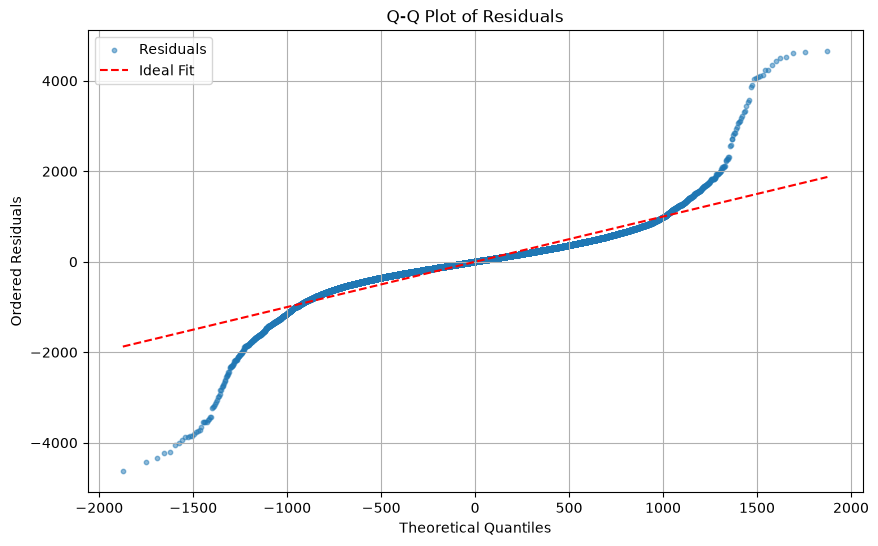

In [59]:
q_q_plot(y, y_pred)

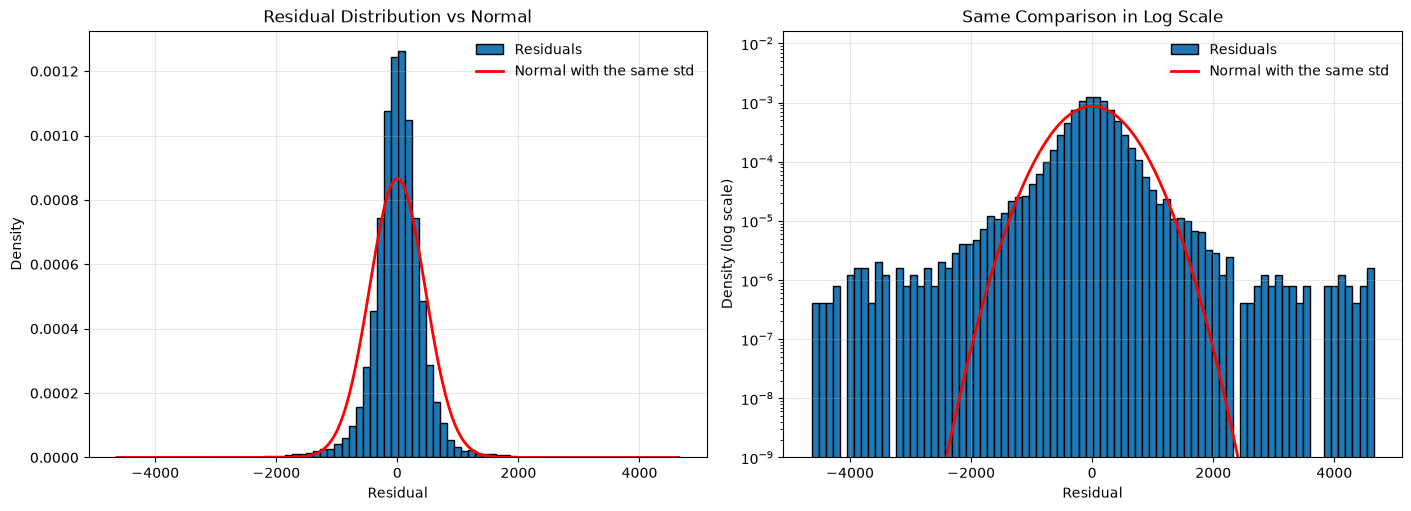

Skewness       :  -0.220   (0 for a normal distribution)
Excess kurtosis:  16.219   (0 for a normal distribution)

Percentage of residuals beyond k standard deviations:


,observed,normal,ratio
k,,,
1,18.4434,31.7311,0.5812
2,4.0111,4.5500,0.8815
3,1.6400,0.2700,6.0747
4,0.7076,0.0063,111.7036
5,0.4264,0.0001,7437.7624


Largest residual in absolute value: 4648 vehicles/hour (10.1 standard deviations)
Largest deviation expected in a normal sample of this size: 4.07 standard deviations (1874 vehicles/hour)
Residual range: [-4636, 4648] vehicles/hour

Excess kurtosis within each hour             :   8.956
Excess kurtosis within each hour and day type:   6.381

Residuals beyond 4 standard deviations: 151
Holidays among them: 33.8%, against 3.3% in the whole training set

Dates contributing the most extreme residuals:


date
2016-07-23    14
2016-07-24     9
2015-08-27     6
2016-11-25     6
2017-08-24     6
Name: count, dtype: int64

Traffic volume per hour on 2016-07-23, the date with most extreme residuals:


hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
traffic_volume,6,8,5,3,7,830,1350,1868,2497,15,...,2,3,7,5,0,1,5,2,1,0


In [60]:
# Quantitative evidence to accompany the Q-Q plot: how the residual distribution
# compares with the normal distribution that has the same standard deviation

residuals = y - y_pred
residual_std = residuals.std()

reference_normal = NormalDist(mu=0.0, sigma=float(residual_std))
grid = np.linspace(residuals.min(), residuals.max(), 400)
density = [reference_normal.pdf(value) for value in grid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax in axes:
    ax.hist(residuals, bins=80, density=True, edgecolor="black", label="Residuals")
    ax.plot(grid, density, color="red", linewidth=2, label="Normal with the same std")
    ax.set_xlabel("Residual")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

axes[0].set_ylabel("Density")
axes[0].set_title("Residual Distribution vs Normal")

# The same comparison in log scale, where the tails become readable
axes[1].set_yscale("log")
axes[1].set_ylim(bottom=1e-9)
axes[1].set_ylabel("Density (log scale)")
axes[1].set_title("Same Comparison in Log Scale")

plt.show()

print("Skewness       : {:>7.3f}   (0 for a normal distribution)".format(pd.Series(residuals).skew()))
print("Excess kurtosis: {:>7.3f}   (0 for a normal distribution)".format(pd.Series(residuals).kurt()))
print()

print("Percentage of residuals beyond k standard deviations:")
tail_comparison = pd.DataFrame(
    [
        {
            "k": k,
            "observed": 100 * np.mean(np.abs(residuals) > k * residual_std),
            "normal": 100 * 2 * (1 - NormalDist().cdf(k)),
        }
        for k in range(1, 6)
    ]
).set_index("k")

tail_comparison["ratio"] = tail_comparison["observed"] / tail_comparison["normal"]
display(tail_comparison.round(4))

print(
    "Largest residual in absolute value: {:.0f} vehicles/hour ({:.1f} standard deviations)".format(
        np.abs(residuals).max(),
        np.abs(residuals).max() / residual_std,
    )
)
print(
    "Largest deviation expected in a normal sample of this size: {:.2f} standard deviations ({:.0f} vehicles/hour)".format(
        NormalDist().inv_cdf(1 - 0.5 / len(residuals)),
        NormalDist().inv_cdf(1 - 0.5 / len(residuals)) * residual_std,
    )
)
print("Residual range: [{:.0f}, {:.0f}] vehicles/hour".format(residuals.min(), residuals.max()))

# Part of the excess kurtosis may be an artifact of pooling residuals with
# different scales, since a mixture of normals with different variances is always
# leptokurtic. Standardizing inside each group removes that effect and isolates
# how much of the deviation from normality is left.
grouped = pd.DataFrame(
    {
        "hr": train_df["hr"].to_numpy(),
        "workingday": train_df["workingday"].to_numpy(),
        "residual": residuals,
    }
)


def standardized_kurtosis(group_columns: list[str]) -> float:
    standardized = grouped.groupby(group_columns)["residual"].transform(
        lambda group: (group - group.mean()) / group.std()
    )
    return standardized.kurt()


print()
print("Excess kurtosis within each hour             : {:>7.3f}".format(standardized_kurtosis(["hr"])))
print("Excess kurtosis within each hour and day type: {:>7.3f}".format(standardized_kurtosis(["hr", "workingday"])))
print()

# The tails are not anonymous noise: we check which observations produce them
extreme = np.abs(residuals) > 4 * residual_std

print("Residuals beyond 4 standard deviations: {}".format(extreme.sum()))
print(
    "Holidays among them: {:.1f}%, against {:.1f}% in the whole training set".format(
        100 * train_df.loc[extreme, "holiday"].mean(),
        100 * train_df["holiday"].mean(),
    )
)
print()
print("Dates contributing the most extreme residuals:")
display(train_df.loc[extreme, "date"].dt.date.value_counts().head(5))

print("Traffic volume per hour on 2016-07-23, the date with most extreme residuals:")
display(train_df.loc[train_df["date"] == "2016-07-23"].set_index("hr")["traffic_volume"].to_frame().T)

> **Question:**
>
> Are the points approximately aligned along a straight line?
>
> What does this indicate about the Gaussian noise assumption used to derive
the MSE objective?
> 
> Based on the evidence from the metrics and plots,
> is linear regression an appropriate model for this dataset?
>
> Justify your conclusion.

**Answer:**

Os diagnósticos indicam que os resíduos não seguem bem uma distribuição Normal. No gráfico Q–Q, os pontos se afastam claramente da reta de referência, principalmente nas extremidades. O histograma reforça essa interpretação: a distribuição observada é mais concentrada próxima de zero e possui caudas muito mais longas que a Normal com o mesmo desvio-padrão. Esse comportamento fica ainda mais evidente no gráfico em escala logarítmica, no qual continuam aparecendo resíduos extremos em regiões onde a densidade prevista pela Normal já seria praticamente nula.

Os valores numéricos confirmam esse padrão. O maior erro absoluto é de aproximadamente 4648 veículos/hora, equivalente a 10.1 desvios-padrão, enquanto em uma amostra Normal deste tamanho esperaríamos um máximo próximo de 4.07 desvios. Portanto, os erros extremos aparecem com frequência e magnitude muito maiores do que seria esperado.

Parte desse comportamento pode ser explicado pela variação da dispersão ao longo do dia observada anteriormente. Quando os resíduos são analisados separadamente por hora, a curtose excedente diminui para 8.956, e cai novamente para 6.381 quando também consideramos o tipo de dia. Isso mostra que diferenças de variabilidade entre horários e entre dias úteis e não úteis explicam parte das caudas pesadas. Entretanto, os valores continuam bastante acima do esperado para uma distribuição Normal, indicando que essa não é a única explicação.

Os erros extremos também não parecem ocorrer de forma completamente aleatória. Entre os 151 resíduos que ultrapassam quatro desvios-padrão, 33.8% pertencem a feriados, embora feriados representem apenas 3.3% do conjunto de treinamento. Isso sugere que um simples indicador de feriado não é suficiente para representar todo o comportamento excepcional desses dias. Algumas datas específicas, como 2016-07-23, também concentram erros muito grandes, podendo representar situações atípicas que o modelo não consegue explicar adequadamente.

Dessa forma, a hipótese de erros Gaussianos com comportamento uniforme ao longo dos dados não é bem sustentada pelos diagnósticos. Isso não significa que a regressão linear seja inadequada, mas sim que ela ainda captura a maior parte da estrutura média do tráfego e apresenta bom desempenho agregado. Entretanto, os gráficos mostram que ela descreve mal a distribuição dos erros, especialmente nos casos extremos e em determinados períodos. Assim, a regressão linear é uma baseline razoável para este problema, mas possui limitações importantes que justificam explorar modelos capazes de representar melhor relações não lineares e a natureza de contagem da variável alvo.

---

## **Polynomial Models**


#### **Protocolo de validação**

**Nota dos estudantes:**

A partir daqui passamos a comparar modelos com capacidades diferentes, o que exige um critério para escolher hiperparâmetros como o grau do polinômio. O erro de treinamento não serve para isso, pois diminui sempre que aumentamos a capacidade do modelo, e o conjunto de teste não pode ser usado para tomar decisões. Por isso, separamos os últimos 20% do conjunto de treinamento como conjunto de validação, preservando a ordem temporal.

É importante ressaltar uma limitação desse corte. O treinamento interno termina em agosto de 2017 e não contém o ano de 2018, de modo que as horas de 2018 da validação caem na categoria de referência de "yr". Assim, o coeficiente de 2018, que os modelos finais estimam com janeiro e fevereiro de 2018, não é avaliado pela validação.

Depois de escolhidos os hiperparâmetros, os modelos finais são re-treinados sobre o conjunto de treinamento completo, de modo que nenhuma observação seja desperdiçada.

In [61]:
# Decisions about capacity and learning rate cannot be made on the test set, and the
# training error always decreases with capacity, so we hold out the last 20% of the
# training set, keeping the temporal order, as a validation set
validation_split = int(0.8 * len(train_df))

inner_train_df = train_df[:validation_split]
val_df = train_df[validation_split:]

# The preprocessing statistics come only from the inner training set, so that the
# validation set is as unseen as the test set will be
X_inner, y_inner = preprocess_data(inner_train_df, reference_df=inner_train_df)
X_val, y_val = preprocess_data(val_df, reference_df=inner_train_df)

print(
    "Inner training set: {} samples, from {} to {}".format(
        len(inner_train_df),
        inner_train_df["date"].min().date(),
        inner_train_df["date"].max().date(),
    )
)
print(
    "Validation set    : {} samples, from {} to {}".format(
        len(val_df),
        val_df["date"].min().date(),
        val_df["date"].max().date(),
    )
)

print("Years in the inner training set:", sorted(inner_train_df["yr"].unique().tolist()))
print("Hours per year in the validation set:", val_df["yr"].value_counts().sort_index().to_dict())


def evaluate(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> dict[str, float]:
    """Computes every metric at once, so that models can be compared in a single table."""
    return {
        "mse": mse(y_true, y_pred),
        "rmse": np.sqrt(mse(y_true, y_pred)),
        "mae": mae(y_true, y_pred),
        "r2_score": r2_score(y_true, y_pred),
    }

Inner training set: 17072 samples, from 2015-06-11 to 2017-08-25
Validation set    : 4269 samples, from 2017-08-25 to 2018-02-19
Years in the inner training set: [0, 1, 2]
Hours per year in the validation set: {2: 3072, 3: 1197}


/tmp/ipykernel_152618/1047744219.py:62: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  categorical[column] = pd.Categorical(


Linear regression assumes that the relationship between the features and the
target is linear.
However, in many real-world situations the relationship between
a variable and the output may be curved or more complex.

For example, suppose that the traffic volume grows as the temperature rises from
a freezing morning up to a comfortable level, but then stops growing (or even
decreases) once the weather becomes too hot.
A straight line would not be able to capture this behavior.

One way to increase the flexibility of linear regression is to transform the
input features.
Instead of using raw variables $x_i$, we can include higher
powers of it, creating new features such as $x_i^2$, $x_i \cdot x_j$, and so on.

For instance, a quadratic model can be written as

$$y \approx \beta_0 + \beta_1 x + \beta_2 x^2.$$

Although this model is nonlinear with respect to the original variables,
it is still **linear in the parameters** $\beta$.
Because of this, the same training methods used for linear regression can still
be applied.

The effect is an increased set of possible models that can describe the relationship
between $x$ and $y$ via parameters $\beta$.

In practice, polynomial regression is implemented by **expanding the feature
space**.
For example, if the original input is $(x_1, x_2)$, a polynomial expansion of
degree two could produce the new feature vector

$$(x_1, x_2, x_1^2, x_2^2, x_1 x_2).$$

The regression model is then applied to this expanded set of features.
This transformation allows the model to capture nonlinear relationships while
keeping the optimization problem simple.

### **Model Capacity and Overfitting**

Increasing the polynomial degree increases the **capacity** of the model. A
higher-degree polynomial can represent more complex relationships in the data.

However, a model that is too flexible may start fitting the noise present in
the training data instead of the underlying relationship. This phenomenon is
called **overfitting**.

As the polynomial degree increases:

- The training error usually decreases.
- The test error may start increasing after a certain point.

This happens because the model becomes too specialized to the training dataset.

### **Implementation**

(1.0 points) Implement the `polynomial_expansion` function that expands the input features
to polynomial features of degree at most $d$.

Instead of using only the original variables, now include polynomial terms with
different degree values, for example, $d = 2, 3, \dots$.
This makes the model more flexible and can represent non-linear relationships
between the predictors and the target.

Remember to test for different learning rates, similar to what was done previously.

**Nota dos estudates:**

A expansão polinomial cria novas features a partir de potências e interações das variáveis originais, permitindo que a regressão represente relações mais complexas do que uma combinação puramente linear.

Neste trabalho, optamos por aplicar essa expansão apenas às três features contínuas ("temp", "rain_1h" e "clouds_all"). Grande parte das demais colunas resulta de one-hot encoding e, portanto, é binária. Elevar essas variáveis a potências não acrescentaria informação, e expandir todas as combinações possíveis aumentaria muito a dimensionalidade do problema. Com as 78 features do modelo original, uma expansão completa produziria 3159 features no grau 2 e mais de 85 mil no grau 3. Embora algumas interações entre variáveis categóricas pudessem ser informativas, optamos por não incluí-las para manter o modelo computacionalmente viável e facilitar a interpretação dos resultados.

Utilizamos PolynomialFeatures para gerar os termos polinomiais das features contínuas, sem adicionar uma coluna constante, pois o modelo de regressão já possui um intercepto próprio. Após a expansão, o bloco polinomial é novamente padronizado para manter as novas features em escalas comparáveis e evitar que diferenças de escala prejudiquem a convergência do gradient descent. Sem a biblioteca, o equivalente seria percorrer as combinações com repetição dos índices e multiplicar as colunas escolhidas:

```python
for degree in range(1, d + 1):
    for combination in itertools.combinations_with_replacement(range(k), degree):
        term = np.prod(continuous[:, combination], axis=1)
```

Dessa forma, o aumento de desempenho entre os diferentes graus pode ser interpretado principalmente como consequência do aumento da capacidade do modelo, e não de diferenças no comportamento do processo de otimização.

In [62]:
from sklearn.preprocessing import PolynomialFeatures


def polynomial_expansion(X: NDArray[np.float64], d: int) -> NDArray[np.float64]:
    """
    Expands the continuous block of X into every monomial of degree 1 to d.

    Only the continuous features are expanded. The remaining columns are one-hot
    indicators, for which the expansion is useless: x**2 == x for a binary column,
    and the product of two indicators of the same categorical variable is always
    zero. The indicators are passed through unchanged.
    """
    n_continuous = len(CONTINUOUS_FEATURES)
    continuous, indicators = X[:, :n_continuous], X[:, n_continuous:]

    # include_bias=False: the constant column is already covered by the model bias
    expansion = PolynomialFeatures(degree=d, include_bias=False).fit_transform(continuous)

    return np.column_stack([expansion, indicators])

Validation R² per degree and learning rate (NaN means the run diverged):


learning_rate,0.01,0.05,0.10,0.50
degree,,,,
1,0.9034,0.9289,0.9299,0.93
2,0.9028,0.9294,0.9305,NaN
3,0.9023,0.9282,0.9292,NaN
4,0.9028,0.9286,NaN,NaN



Summary per degree:


,columns,rank,condition_number,optimum_train_r2,optimum_val_r2,learning_rate,train_r2,val_r2,val_mae
degree,,,,,,,,,
1,78,79,90.2578,0.9475,0.9300,0.50,0.9475,0.9300,347.2791
2,84,85,123.6799,0.9477,0.9306,0.10,0.9475,0.9305,346.4903
3,94,95,185.1159,0.9479,0.9294,0.10,0.9477,0.9292,350.3128
4,109,110,966.8210,0.9480,0.9298,0.05,0.9473,0.9286,355.4324


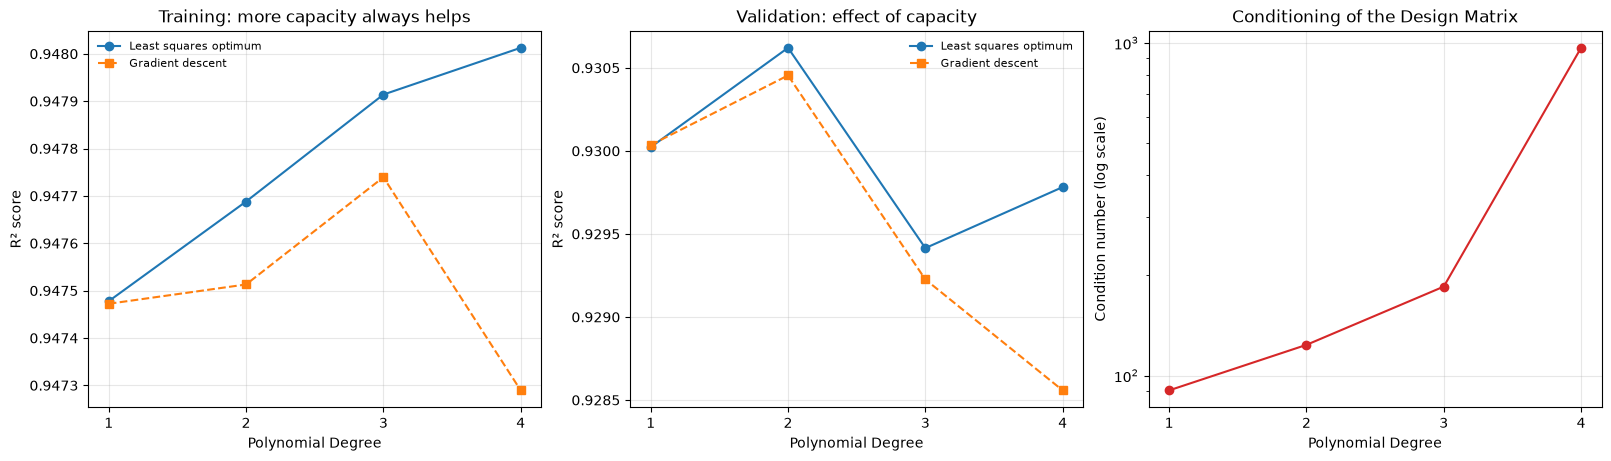


Largest stable learning rate per degree:


degree
1    0.50
2    0.10
3    0.10
4    0.05
Name: learning_rate, dtype: float64

Share of zeros in the continuous features, whose powers stay close to the variable itself:
  temp          0.1% zeros
  rain_1h      96.3% zeros
  clouds_all    5.5% zeros


In [63]:
# Expanding changes the scale of the columns, since a cubed standardized variable is
# no longer on the same scale as the variable itself, and gradient descent would crawl
# along the smaller directions. We standardize the polynomial block again, with
# statistics taken from the training split only, and leave the indicators as 0/1.
def build_polynomial(X_fit: NDArray[np.float64], X_apply: NDArray[np.float64], d: int):
    """Expands both matrices to degree d, standardizing with X_fit statistics."""
    expanded_fit = polynomial_expansion(X_fit, d)
    expanded_apply = polynomial_expansion(X_apply, d)

    n_indicators = X_fit.shape[1] - len(CONTINUOUS_FEATURES)
    polynomial_block = slice(0, expanded_fit.shape[1] - n_indicators)

    mean = expanded_fit[:, polynomial_block].mean(axis=0)
    std = expanded_fit[:, polynomial_block].std(axis=0)
    std = np.where(std == 0.0, 1.0, std)

    expanded_fit[:, polynomial_block] = (expanded_fit[:, polynomial_block] - mean) / std
    expanded_apply[:, polynomial_block] = (expanded_apply[:, polynomial_block] - mean) / std

    return expanded_fit, expanded_apply


degrees = [1, 2, 3, 4]
polynomial_lrs = [0.01, 0.05, 0.1, 0.5]

polynomial_search = []
polynomial_reference = []

for degree in degrees:
    poly_inner, poly_val = build_polynomial(X_inner, X_val, degree)

    # Least squares solution of the same design matrix. It is not used as a model,
    # only as the optimum that gradient descent is trying to reach, so that we can
    # tell a capacity effect apart from an optimization failure.
    design = np.hstack([np.ones((len(poly_inner), 1)), poly_inner])
    design_val = np.hstack([np.ones((len(poly_val), 1)), poly_val])
    coefficients, *_ = np.linalg.lstsq(design, y_inner, rcond=None)

    polynomial_reference.append(
        {
            "degree": degree,
            "columns": poly_inner.shape[1],
            "rank": np.linalg.matrix_rank(design),
            "condition_number": np.linalg.cond(design),
            "optimum_train_r2": r2_score(y_inner, design @ coefficients),
            "optimum_val_r2": r2_score(y_val, design_val @ coefficients),
        }
    )

    for learning_rate in polynomial_lrs:
        model = LinearRegression(learning_rate=learning_rate, n_iterations=10000)

        # A learning rate that is too large for the conditioning of this degree makes
        # the weights grow until they overflow, and numpy warns at every operation
        # that follows. Those runs are expected, detected right below and reported as
        # NaN, so the warnings are silenced here and nowhere else.
        with np.errstate(over="ignore", invalid="ignore"):
            model.fit(poly_inner, y_inner)
            train_predictions = model.predict(poly_inner)
            val_predictions = model.predict(poly_val)

        if not np.isfinite(val_predictions).all():
            polynomial_search.append({"degree": degree, "learning_rate": learning_rate, "train_r2": np.nan, "val_r2": np.nan, "val_mae": np.nan})
            continue

        polynomial_search.append(
            {
                "degree": degree,
                "learning_rate": learning_rate,
                "train_r2": r2_score(y_inner, train_predictions),
                "val_r2": r2_score(y_val, val_predictions),
                "val_mae": mae(y_val, val_predictions),
            }
        )

polynomial_search = pd.DataFrame(polynomial_search)
polynomial_reference = pd.DataFrame(polynomial_reference).set_index("degree")

print("Validation R² per degree and learning rate (NaN means the run diverged):")
display(polynomial_search.pivot(index="degree", columns="learning_rate", values="val_r2").round(4))

# Best learning rate for each degree, chosen on the validation set
best_per_degree = polynomial_search.dropna().loc[polynomial_search.dropna().groupby("degree")["val_r2"].idxmax()].set_index("degree")

summary = polynomial_reference.join(best_per_degree)
print("\nSummary per degree:")
display(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# The two effects live on different scales, so they get one panel each
for ax, (column_optimum, column_gd, title) in zip(
    axes,
    [
        ("optimum_train_r2", "train_r2", "Training: more capacity always helps"),
        ("optimum_val_r2", "val_r2", "Validation: effect of capacity"),
    ],
):
    ax.plot(summary.index, summary[column_optimum], marker="o", label="Least squares optimum")
    ax.plot(summary.index, summary[column_gd], marker="s", linestyle="--", label="Gradient descent")

    ax.set_xlabel("Polynomial Degree")
    ax.set_ylabel("R² score")
    ax.set_title(title)
    ax.set_xticks(degrees)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.3)

# The numerical price of expanding, which limits the usable learning rate
axes[2].plot(summary.index, summary["condition_number"], marker="o", color="tab:red")

axes[2].set_yscale("log")
axes[2].set_xlabel("Polynomial Degree")
axes[2].set_ylabel("Condition number (log scale)")
axes[2].set_title("Conditioning of the Design Matrix")
axes[2].set_xticks(degrees)
axes[2].grid(alpha=0.3)

plt.show()

print("\nLargest stable learning rate per degree:")
display(polynomial_search.dropna().groupby("degree")["learning_rate"].max())

print("Share of zeros in the continuous features, whose powers stay close to the variable itself:")
for feature in CONTINUOUS_FEATURES:
    print("  {:<11} {:>5.1f}% zeros".format(feature, 100 * (inner_train_df[feature] == 0).mean()))

> **Question:**
> 
> How does the training error of the polynomial model compare with the
training error of the linear regression model?
>
> Does this result indicate that it is better than the linear
model for this problem?
>
> Which degree would you select to explore?

**Answer:**

O aumento do grau reduz ligeiramente o erro de treinamento. O $R^2$ de treinamento passa de 0.9475 no modelo linear para 0.9477, 0.9479 e 0.9480 nos graus 2, 3 e 4. Portanto, os termos polinomiais realmente aumentam a capacidade do modelo, mas o ganho no ajuste do treinamento é muito pequeno.

Esse menor erro de treinamento, porém, não significa que os modelos de maior grau sejam necessariamente melhores. Na validação, o melhor resultado ocorre no grau 2, com $R^2$ próximo de 0.9305 e MAE de aproximadamente 346.5 veículos/hora, contra 0.9300 e 347.3 no modelo linear. A partir do grau 3, o desempenho de validação volta a piorar. Assim, aumentar a complexidade além do grau 2 melhora o ajuste aos dados de treinamento sem produzir melhora correspondente em dados posteriores, indicando que a capacidade adicional tem pouca utilidade para generalização.

Os gráficos também mostram que parte da piora nos graus mais altos está relacionada à própria otimização. À medida que o grau aumenta, a matriz de entrada se torna mais difícil de otimizar e o gradient descent se distancia da solução ótima, principalmente no grau 4. Portanto, a diferença observada nos graus 3 e 4 não deve ser interpretada exclusivamente como overfitting: há também uma dificuldade crescente de convergência.

Escolheríamos, portanto, grau 2 com learning rate 0.1 para continuar a análise. Ele apresenta o melhor desempenho de validação entre as configurações testadas, mantendo uma complexidade relativamente próxima à do modelo linear. Ainda assim, a melhora é pequena, então os resultados não indicam que a regressão polinomial seja claramente superior à linear. Eles sugerem apenas que existe algum benefício em permitir relações não lineares entre as features contínuas, mas que a maior parte da estrutura relevante do problema já está sendo capturada pelo conjunto de features utilizado no modelo linear.

---
### **Visualizing Predictions**

(1.5 points) Inspect the predicted vs observed plot, compare with the same plots used in the
linear model, are they different?

Explore how the results change and link them with training error in the polynomial
model.

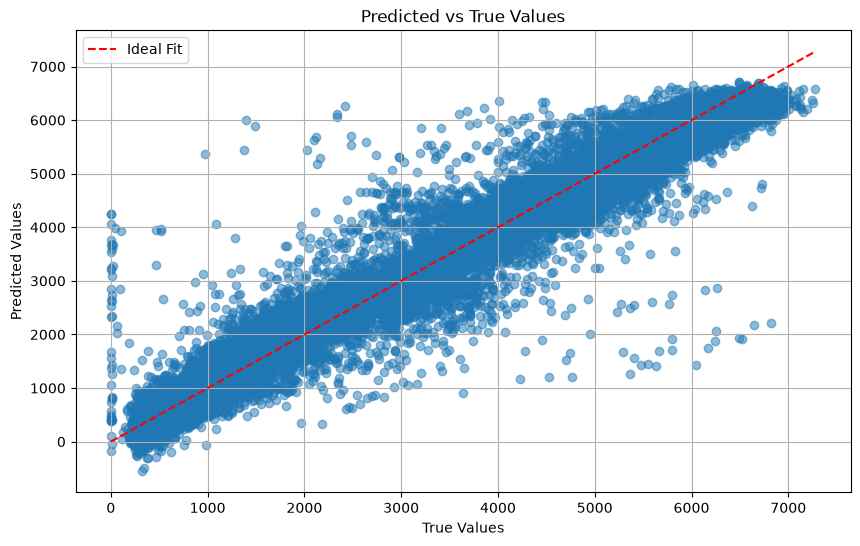

In [64]:
best_lr = 0.1 # Choose the best learning rate based on the previous graphs
best_degree = 2 # Choose the best degree based on experimentation with different degrees and analyzing the results

# build_polynomial standardizes the expanded block with statistics taken from its
# first argument, which here is the training matrix itself
X_poly, _ = build_polynomial(X, X, best_degree)

best_poly_model = LinearRegression(learning_rate=best_lr, n_iterations=10000)
best_poly_model.fit(X_poly, y)
y_pred = best_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

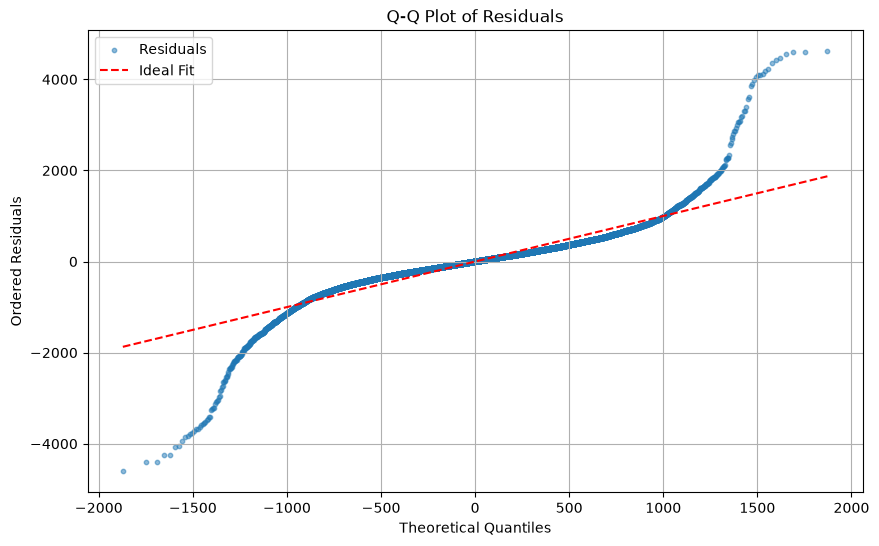

In [65]:
q_q_plot(y, y_pred)

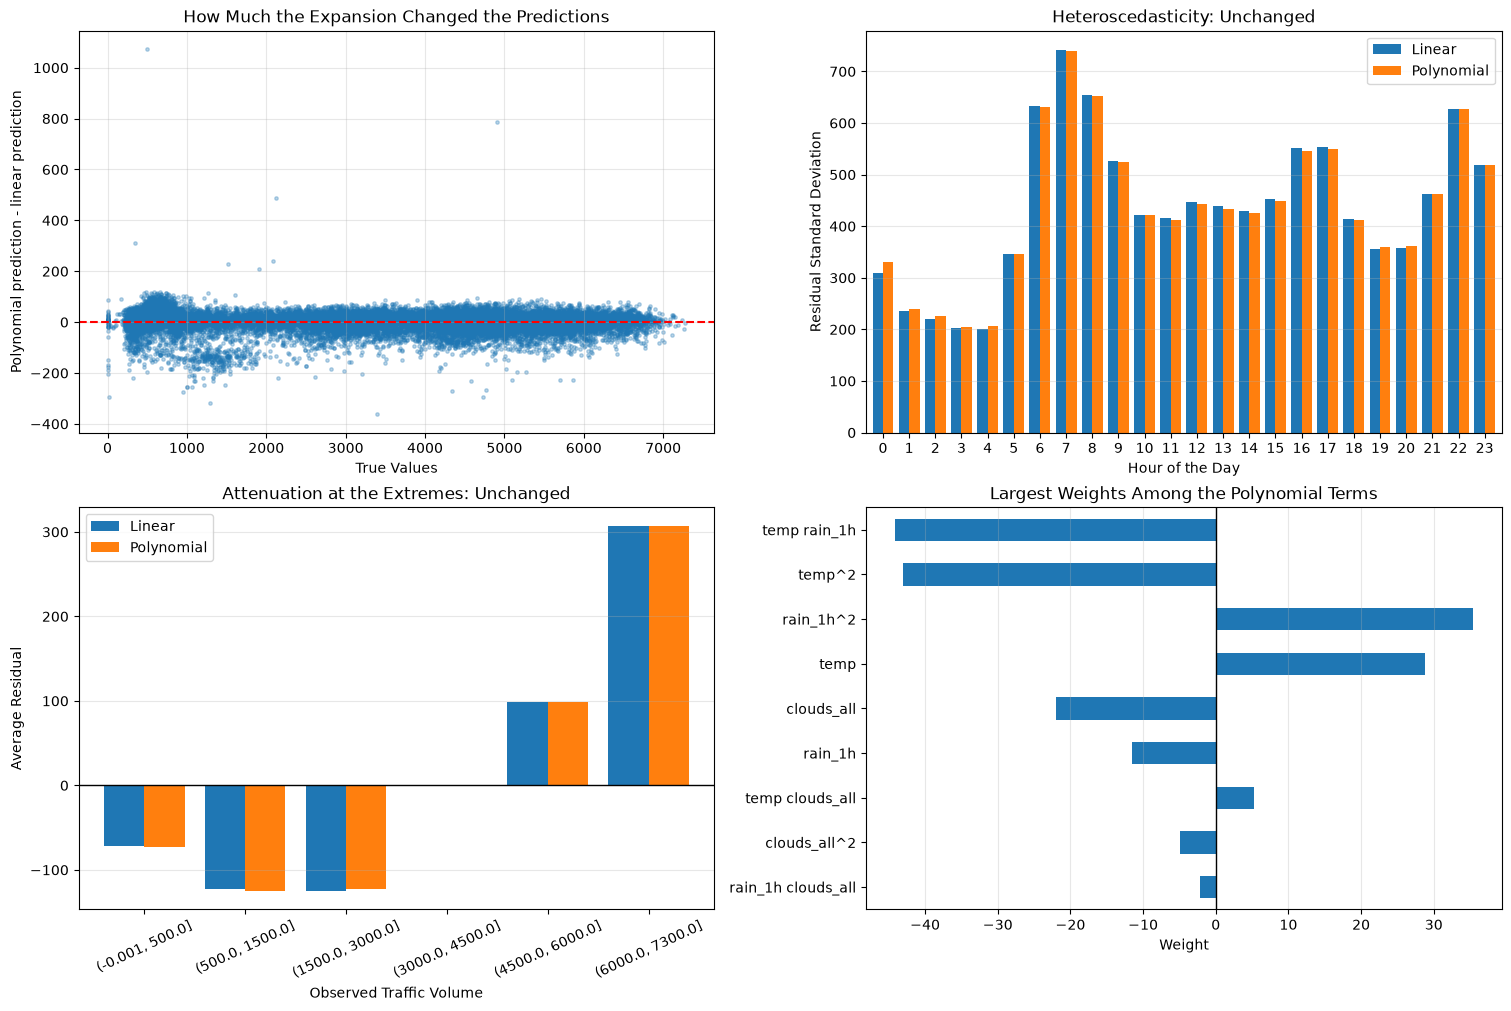

Correlation between the two sets of predictions: 0.99978
Mean absolute difference between them: 27.3 vehicles/hour

Training set comparison:


,mse,rmse,mae,r2_score,negative_predictions,smallest_prediction,residual_skewness,residual_kurtosis
Linear,212034.6616,460.4722,300.6659,0.9450,74,-807.7682,-0.2203,16.2188
Polynomial,211481.3818,459.8710,301.2170,0.9452,81,-556.9380,-0.2074,16.0123


Residual dispersion per hour, smallest and largest (vehicles/hour):


,Linear,Polynomial
min,201.2,205.3
max,741.9,739.5


Average residual per observed traffic level:


,Linear,Polynomial
level,,
"(-0.001, 500.0]",-72.3,-73.1
"(500.0, 1500.0]",-123.2,-125.1
"(1500.0, 3000.0]",-124.7,-122.8
"(3000.0, 4500.0]",-1.3,-0.9
"(4500.0, 6000.0]",98.2,98.3
"(6000.0, 7300.0]",307.3,307.0


Weights of the polynomial terms, largest in absolute value first:


,weight
temp rain_1h,-44.2
temp^2,-43.0
rain_1h^2,35.4
temp,28.8
clouds_all,-22.0
rain_1h,-11.6
temp clouds_all,5.3
clouds_all^2,-4.9
rain_1h clouds_all,-2.1


In [66]:
# The diagnostics from the linear model, recomputed side by side, to check whether
# the extra capacity fixed any of the systematic deviations we had found

polynomial_predictions = y_pred
linear_predictions = best_linear_model.predict(X)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# Plot 1: how far the polynomial moved each prediction
axes[0, 0].scatter(y, polynomial_predictions - linear_predictions, alpha=0.3, s=6)
axes[0, 0].axhline(0, color="red", linestyle="--")

axes[0, 0].set_xlabel("True Values")
axes[0, 0].set_ylabel("Polynomial prediction - linear prediction")
axes[0, 0].set_title("How Much the Expansion Changed the Predictions")
axes[0, 0].grid(alpha=0.3)

# Plot 2: residual dispersion per hour, the heteroscedasticity from before
residuals_by_model = pd.DataFrame(
    {
        "hr": train_df["hr"].to_numpy(),
        "Linear": y - linear_predictions,
        "Polynomial": y - polynomial_predictions,
    }
)
hourly_spread = residuals_by_model.groupby("hr")[["Linear", "Polynomial"]].std()

hourly_spread.plot(kind="bar", ax=axes[0, 1], width=0.8)

axes[0, 1].set_xlabel("Hour of the Day")
axes[0, 1].set_ylabel("Residual Standard Deviation")
axes[0, 1].set_title("Heteroscedasticity: Unchanged")
axes[0, 1].tick_params(axis="x", labelrotation=0)
axes[0, 1].grid(axis="y", alpha=0.3)

# Plot 3: average residual per observed level, the attenuation from before
level = traffic_level(y)
bias_by_level = pd.DataFrame(
    {
        "level": level,
        "Linear": y - linear_predictions,
        "Polynomial": y - polynomial_predictions,
    }
).groupby("level", observed=True)[["Linear", "Polynomial"]].mean()

bias_by_level.plot(kind="bar", ax=axes[1, 0], width=0.8)
axes[1, 0].axhline(0, color="black", linewidth=1)

axes[1, 0].set_xlabel("Observed Traffic Volume")
axes[1, 0].set_ylabel("Average Residual")
axes[1, 0].set_title("Attenuation at the Extremes: Unchanged")
axes[1, 0].tick_params(axis="x", labelrotation=25)
axes[1, 0].grid(axis="y", alpha=0.3)

# Plot 4: where the extra capacity actually went
n_polynomial_terms = X_poly.shape[1] - (X.shape[1] - len(CONTINUOUS_FEATURES))

term_names = (
    PolynomialFeatures(degree=best_degree, include_bias=False)
    .fit(np.zeros((1, len(CONTINUOUS_FEATURES))))
    .get_feature_names_out(CONTINUOUS_FEATURES)
)
term_weights = pd.Series(best_poly_model.weights[:n_polynomial_terms], index=term_names)
largest_terms = term_weights.reindex(term_weights.abs().sort_values().index)[-10:]

largest_terms.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].axvline(0, color="black", linewidth=1)

axes[1, 1].set_xlabel("Weight")
axes[1, 1].set_title("Largest Weights Among the Polynomial Terms")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.show()

print("Correlation between the two sets of predictions: {:.5f}".format(
    np.corrcoef(linear_predictions, polynomial_predictions)[0, 1]
))
print("Mean absolute difference between them: {:.1f} vehicles/hour".format(
    np.mean(np.abs(linear_predictions - polynomial_predictions))
))
print()

comparison = pd.DataFrame(
    {
        "Linear": evaluate(y, linear_predictions),
        "Polynomial": evaluate(y, polynomial_predictions),
    }
).T
comparison["negative_predictions"] = [int((linear_predictions < 0).sum()), int((polynomial_predictions < 0).sum())]
comparison["smallest_prediction"] = [linear_predictions.min(), polynomial_predictions.min()]
comparison["residual_skewness"] = [pd.Series(y - linear_predictions).skew(), pd.Series(y - polynomial_predictions).skew()]
comparison["residual_kurtosis"] = [pd.Series(y - linear_predictions).kurt(), pd.Series(y - polynomial_predictions).kurt()]

print("Training set comparison:")
display(comparison.round(4))

print("Residual dispersion per hour, smallest and largest (vehicles/hour):")
display(hourly_spread.agg(["min", "max"]).round(1))

print("Average residual per observed traffic level:")
display(bias_by_level.round(1))

print("Weights of the polynomial terms, largest in absolute value first:")
display(term_weights.reindex(term_weights.abs().sort_values(ascending=False).index).round(1).to_frame("weight"))

> **Question:**
> 
> Does the polynomial model appear to capture relationships that the linear model
could not?
>
> Did this choice fix the systematic deviations previously observed?


**Answer:**

O modelo polinomial parece capturar apenas uma pequena quantidade de estrutura adicional em relação ao modelo linear. No treinamento, o $R^2$ passa de aproximadamente 0.9450 para 0.9452 e o MSE diminui ligeiramente, enquanto o MAE permanece praticamente inalterado. Além disso, as previsões dos dois modelos têm correlação de 0.99978 e diferem, em média, apenas 27.3 veículos/hora. Isso explica por que os gráficos de valores preditos e observados são visualmente muito semelhantes.

Os pesos dos termos polinomiais mostram onde a capacidade adicional foi usada. Os maiores em módulo são a interação entre "temp" e "rain_1h", com −44.2, o quadrado de "temp", com −43.0, e o quadrado de "rain_1h", com +35.4. O peso negativo de "temp" ao quadrado indica uma relação côncava, com tráfego menor nas temperaturas extremas, o que é uma estrutura plausível que o modelo linear não conseguia representar.

Nenhum dos desvios identificados anteriormente foi corrigido. O modelo polinomial ainda produz previsões negativas — 81 casos contra 74 no modelo linear — e a dispersão dos resíduos por hora praticamente não muda. O comportamento nos extremos também permanece semelhante: ambos tendem a superestimar volumes muito baixos e subestimar os maiores volumes. O gráfico Q–Q continua apresentando fortes desvios nas caudas, indicando que a expansão polinomial também não resolveu a estrutura anômala dos resíduos.

Esse resultado esclarece a natureza do problema. O que faltava ao modelo linear não era flexibilidade para representar a média condicional, pois ele já descrevia bem a estrutura dominante do tráfego por meio das indicadoras de hora e da interação com o tipo de dia. O que faltava era uma descrição adequada da distribuição do alvo, que é uma contagem não-negativa com variância crescente. Como parte importante das limitações está relacionada à própria natureza do target e ao comportamento da variabilidade dos erros, motiva-se explorar um modelo específico para dados de contagem, como a regressão de Poisson.

---
## **Count Data and Model Assumptions**

> **IMPORTANT:** This section is optional and will yield **additional 1.0 points**
> to your assignment.
> We recommend you finish the mandatory sections above before attempting to
> switch to additional assumptions and model decisions this section introduces.
>
> Despite this section being optional, we strongly advise you on exploring
> the following models, not only as an additional model to your toolbox, but
> from the modeling perspective of statistical learning.

\
In the previous sections we used linear regression and polynomial models
to predict the hourly traffic volume.
However, the target variable in this dataset has a particular characteristic,
it represents a **count**.

This is important because, when we were stating the assumptions in the linear model,
we had no hard assumption on the target nature, it was a real number.
In counting problems, the target is a positive integer number with specific
characteristics that are ignored.

Therefore, a possible direction of improvement is choosing the model that best
aligns with our problem, exploiting the domain knowledge we have to produce better
estimators.

In this section, we are going to use a new linear model with a different
probabilistic assumption for the target variable.

### **Poisson distribution**

A common model for count data is the **Poisson distribution**.
This distribution describes the probability of observing a number of events
during a fixed interval.

For example, the number of students achieving a low and high mark in an exam,
the number of meteorites that strike Earth in a year, or the number of vehicles
crossing a sensor in one hour.

The Poisson distribution is parameterized by a rate parameter $\lambda > 0$,
which represents the expected number of events in a time unit.

The probability of observing a value $y$ is

$$p(y \mid \lambda) = \frac{\lambda^y e^{-\lambda}}{y!}.$$

In this model, both the mean and the variance are equal to $\lambda$.
Therefore, when predicting, returning the expected count value $\hat{y}$ is
equivalent to returning $\lambda$ itself.

### **Poisson Regression**
Poisson regression is a special case of the Generalized Linear Models along with
Linear and Logistic regression.
The idea here is to model $\lambda$ as a function of the input $x$ and parameters
$\beta$ and describe $p(y \mid x, \beta) = p(y \mid \lambda)$.

Again, as a linear model, we want to relate the linear combination
$\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$ to this new parameter $\lambda$,
that is strictly positive.

To make this to happen, we define a **link function** $g$ such that $g(\lambda)$
can vary from -$\infty$ to $\infty$, thus allowing that

$$g(\lambda) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n,$$
as $\beta$ and $x$ are unconstrained.

A common link function used in Poisson regression is the $\log$, making

$$\hat{y} = \lambda = \exp(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n),$$
turning the previously unconstrained prediction in a strictly positive count
parameter, and then addressing a probability using the Poisson distribution.

#### **Implementation**

(1.0 points) Derive the loss function of the Poisson Regression,

$$-\log \mathcal{L}(\beta) = -\sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
using the Poisson distribution instead of the Gaussian distribution for $p(y^i \mid x^i, \beta)$.

**Hint:** You can ignore constant terms and scales in the objective function to
obtain a MSE-like gradient.

> **Question:**
>
> Is the negative log-likelihood the same?
>
> Is it equivalent to a Linear regressor predicting $\log y$ instead of $y$?

**Answer:**

Partindo da distribuição de Poisson com $\lambda = \exp(x^T\beta)$, e portanto $\log \lambda = x^T\beta$:

$$p(y \mid x, \beta) = \frac{\lambda^y e^{-\lambda}}{y!} \quad \Longrightarrow \quad \log p(y \mid x, \beta) = y \log \lambda - \lambda - \log(y!) = y\,x^T\beta - \exp(x^T\beta) - \log(y!)$$

Somando sobre as observações e invertendo o sinal, o termo $\log(y!)$ não depende de $\beta$ e pode ser descartado, o que leva ao critério

$$-\log \mathcal{L}(\beta) \propto \sum_{i=1}^{n} \left[ \exp({x^i}^T\beta) - y^i\, {x^i}^T\beta \right], \qquad \nabla_\beta = \frac{1}{n} X^T (\lambda - y)$$

*Is the negative log-likelihood the same?*

Não, a função objetivo é diferente. O que coincide é a **forma do gradiente**: na regressão linear ele é proporcional a $X^T(\hat{y} - y)$ e aqui é $X^T(\lambda - y)$, ou seja, em ambos os casos o gradiente é a matriz de features multiplicada pelo erro entre a predição e o valor observado. A diferença está apenas em como a predição é obtida, $x^T\beta$ contra $\exp(x^T\beta)$. Essa é uma propriedade geral dos modelos lineares generalizados quando se usa a função de ligação canônica, e é o que permite reaproveitar a mesma estrutura de gradiente descendente.

*Is it equivalent to a Linear regressor predicting $\log y$ instead of $y$?*

Não. A regressão de Poisson modela $\log E[y \mid x] = x^T\beta$, enquanto um regressor linear sobre $\log y$ modela $E[\log y \mid x] = x^T\beta$. Pela desigualdade de Jensen, $E[\log y] \leq \log E[y]$, de modo que as duas abordagens estimam quantidades distintas, e converter a predição de volta com uma exponencial introduz viés de retransformação.

Há ainda duas diferenças práticas. A primeira é que $\log y$ é indefinido quando $y = 0$, situação que ocorre em duas observações do conjunto de treinamento, o que obrigaria a descartá-las ou a somar uma constante arbitrária. A segunda é a estrutura de variância assumida: a regressão de Poisson supõe variância igual à média, crescendo com o nível previsto, enquanto a regressão linear sobre $\log y$ supõe variância constante na escala logarítmica, isto é, erro relativo constante.

---
Implement this regression using the same pattern as the `LinearRegression` and
train a Poisson regression model using the same training dataset used
previously, selecting appropriate learning rates.

> **Hint:** the counts in this dataset are large, so $\exp(x^T\beta)$ can easily
> overflow during the first iterations. If you run into `inf`/`nan`, think about
> the scale of your features and of the initial prediction before blaming the
> learning rate alone.

In [67]:
class PoissonRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None
        self.loss_history: list[float] = []

    def fit(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        n_samples, n_features = X.shape

        # Initialize parameters. With a zero bias the first prediction would be
        # exp(0) = 1, while the counts are in the thousands, so the first gradients
        # would be huge. Starting at log(mean) puts the initial rate at the right
        # order of magnitude and keeps exp() away from overflow.
        weights = np.zeros(n_features)
        bias = float(np.log(y.mean()))

        loss_history = []

        # Gradient descent on the Poisson negative log-likelihood
        for _ in range(self.n_iterations):
            # Forward. The linear predictor is clipped before exp() so that a bad
            # learning rate saturates the model instead of producing inf and nan.
            linear_prediction = np.clip(np.dot(X, weights) + bias, -30.0, 30.0)
            rate = np.exp(linear_prediction)

            # Objective without the constant log(y!) term, tracked to tell an
            # actual descent apart from a divergence
            loss_history.append(float(np.mean(rate - y * linear_prediction)))

            # Error
            error = rate - y

            # Gradient calculation
            dw = np.dot(X.T, error) / n_samples
            db = np.mean(error)

            # Gradient update
            weights -= self.learning_rate * dw
            bias -= self.learning_rate * db

        # Save the learned parameters
        self.weights = weights
        self.bias = bias
        self.loss_history = loss_history

    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"

        return np.exp(np.clip(np.dot(X, self.weights) + self.bias, -30.0, 30.0))

Iterations in which the objective increased, out of 7999 (NaN metrics mean an unstable run):


,overshooting_steps,train_r2,val_r2,val_mae,val_rmse
learning_rate,,,,,
0.000001,0,0.7910,0.7642,801.5350,962.1275
0.000010,0,0.9275,0.9047,439.9148,611.8547
0.000050,0,0.9460,0.9261,363.5625,538.5641
0.000100,0,0.9472,0.9283,352.6999,530.5246
0.000200,0,0.9474,0.9288,349.3084,528.6485
0.000500,5047,NaN,NaN,NaN,NaN
0.001000,4,NaN,NaN,NaN,NaN


Best learning rate on the validation set: 0.0002


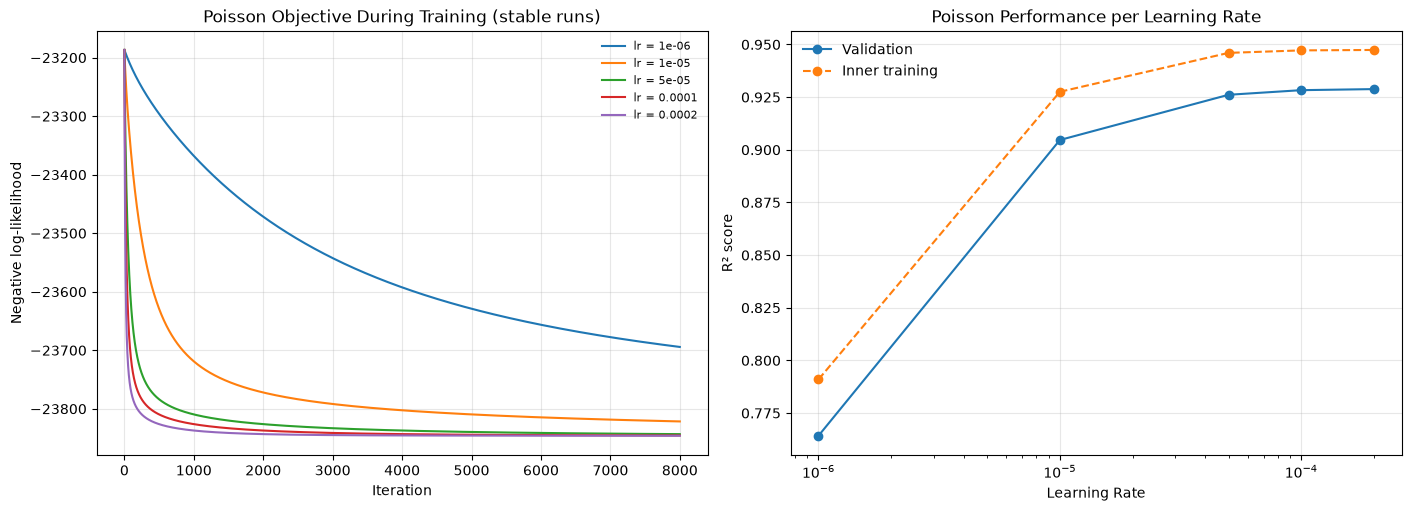

With lr = 0.001 the predictions on the inner training set collapse to the range [0.0, 0.0],
and the resulting MSE of 14528991 is exactly mean(y**2) = 14528991, the error of always predicting zero.


In [68]:
# Learning rate search for the Poisson model, selected on the validation set.
# The usable scale is much smaller than for the linear model, because the gradient
# carries the rate itself, which is in the thousands rather than in units.
poisson_learning_rates = [1e-6, 1e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3]

poisson_models = {}
poisson_search = []


# With a well chosen step size gradient descent decreases the objective at every
# single iteration, so we call a run stable only when it never increases. Checking
# just the final value is not enough: an oscillating run can land on the good side
# of the cycle and look converged.
def increases_in(model: PoissonRegression) -> int:
    return sum(later > earlier for earlier, later in zip(model.loss_history, model.loss_history[1:]))


for learning_rate in poisson_learning_rates:
    model = PoissonRegression(learning_rate=learning_rate, n_iterations=8000)
    model.fit(X_inner, y_inner)
    poisson_models[learning_rate] = model

    train_scores = evaluate(y_inner, model.predict(X_inner))
    val_scores = evaluate(y_val, model.predict(X_val))

    poisson_search.append(
        {
            "learning_rate": learning_rate,
            "overshooting_steps": increases_in(model),
            "train_r2": train_scores["r2_score"],
            "val_r2": val_scores["r2_score"],
            "val_mae": val_scores["mae"],
            "val_rmse": val_scores["rmse"],
        }
    )

poisson_search = pd.DataFrame(poisson_search).set_index("learning_rate")

# The metrics of an unstable run are not meaningful and can reach absurd magnitudes
# (the exploding predictor is clipped, but exp(30) is still around 1e13), so they
# are recorded as NaN, as in the previous sections
unstable = poisson_search["overshooting_steps"] > 0
poisson_search.loc[unstable, ["train_r2", "val_r2", "val_mae", "val_rmse"]] = np.nan

print("Iterations in which the objective increased, out of {} (NaN metrics mean an unstable run):".format(
    len(poisson_models[poisson_learning_rates[0]].loss_history) - 1
))
display(poisson_search.round(4))

best_poisson_lr = poisson_search["val_r2"].idxmax()
print("Best learning rate on the validation set:", best_poisson_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Plot 1: the objective along the iterations, for the stable runs only. Unstable
# runs swing across a range wide enough to hide every other curve.
stable = {
    learning_rate: model
    for learning_rate, model in poisson_models.items()
    if increases_in(model) == 0
}

for learning_rate, model in stable.items():
    axes[0].plot(model.loss_history, label="lr = {}".format(learning_rate))

axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Negative log-likelihood")
axes[0].set_title("Poisson Objective During Training (stable runs)")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(alpha=0.3)

# Plot 2: validation performance against the learning rate
axes[1].plot(poisson_search.index, poisson_search["val_r2"], marker="o", label="Validation")
axes[1].plot(poisson_search.index, poisson_search["train_r2"], marker="o", linestyle="--", label="Inner training")

axes[1].set_xscale("log")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("R² score")
axes[1].set_title("Poisson Performance per Learning Rate")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

plt.show()

# Divergence here is silent: the clipping turns an exploding predictor into a model
# that always predicts zero, instead of producing inf or nan
diverged = poisson_models[1e-3].predict(X_inner)
print(
    "With lr = 0.001 the predictions on the inner training set collapse to the range [{:.1f}, {:.1f}],".format(
        diverged.min(), diverged.max()
    )
)
print(
    "and the resulting MSE of {:.0f} is exactly mean(y**2) = {:.0f}, the error of always predicting zero.".format(
        mse(y_inner, diverged), np.mean(y_inner**2)
    )
)

> **Question:**
>
> Compare the performance of the Poisson models with the Linear Regression model.
> Even though both models rely on a linear combination of the features,
> their predictions are not computed in the same way.
>
> $\hat{y}=x^T\beta$
>
> $\lambda=\exp(x^T\beta)$
>
> Are the predictive performances equivalent?
> Which model appears to produce predictions that better match the data?
>
> Explain why two models that both use a linear predictor can still behave
> very differently. Consider the distributional assumptions and the
> transformation applied to the output.

**Answer:**

As performances são muito próximas quando medidas de forma agregada, mas não são equivalentes, e a diferença aparece justamente onde as premissas dos dois modelos divergem.

Na validação, a regressão linear alcança $R^2$ de 0.9300 e a de Poisson 0.9288, com erro absoluto médio de 347.3 e 349.3 veículos/hora. No conjunto de treinamento completo, cujas tabelas estão na seção de visualização a seguir, os dois modelos empatam em $R^2$ de 0.9450, com MSE de 212035 para a linear e 212080 para a de Poisson. A linear é marginalmente melhor no erro quadrático, o que era esperado, já que ela o minimiza diretamente enquanto a de Poisson otimiza um critério diferente. Pelo erro absoluto médio no treinamento, no entanto, a ordem se inverte: 293.0 contra 300.7 veículos/hora.

A diferença relevante não está nos agregados. A regressão linear produz 74 predições negativas, chegando a −807.8 veículos/hora, enquanto a de Poisson tem predição mínima de 248.9 e não pode produzir valores negativos por construção, pois $\lambda = \exp(x^T\beta)$ é estritamente positivo. Separando o erro absoluto médio por faixa de volume observado, a vantagem se concentra exatamente onde a linear falhava: abaixo de 500 veículos/hora o erro cai de 198.7 para 108.7, uma redução de 45%, e entre 500 e 1500 cai de 257.4 para 218.4. Nas faixas intermediárias e altas a linear é melhor, por margens entre 1% e 7%.

Esse comportamento explica por que dois modelos com o mesmo preditor linear se comportam de forma tão diferente. Na regressão linear os efeitos são aditivos: um coeficiente soma uma quantidade fixa de veículos independentemente do horário. Com a ligação logarítmica, os efeitos passam a ser multiplicativos, pois $\exp(x^T\beta)$ transforma somas no expoente em produtos na escala do alvo, e cada coeficiente representa uma variação percentual. Isso faz com que o erro esperado escale junto com o nível previsto, o que é coerente com a heterocedasticidade observada nas questões anteriores, e impede que a predição cruze o zero nas horas de tráfego baixo.

Cabe ressaltar, porém, que a premissa distribucional da Poisson também é violada. Ela supõe variância igual à média, mas os resíduos de Pearson do modelo ajustado têm desvio-padrão de 8.89, quando deveriam ter aproximadamente 1, e a estatística de dispersão é de 79.4. Ou seja, a variância condicional observada é cerca de oitenta vezes maior que a assumida, um caso claro de superdispersão. O modelo acerta o formato da relação, com suporte positivo e variância crescente com a média, mas subestima fortemente a magnitude dessa variância.

---
### **Visualizing Predictions**

Check how the predictions change when moving from the **Gaussian assumption**
used in linear regression to the **Poisson assumption** used in Poisson regression.

Plot the predicted values against the observed values and compare the
distribution of points with the plots obtained previously.

Pay attention to how the **shape of the point cloud** changes under the
different modeling assumptions.


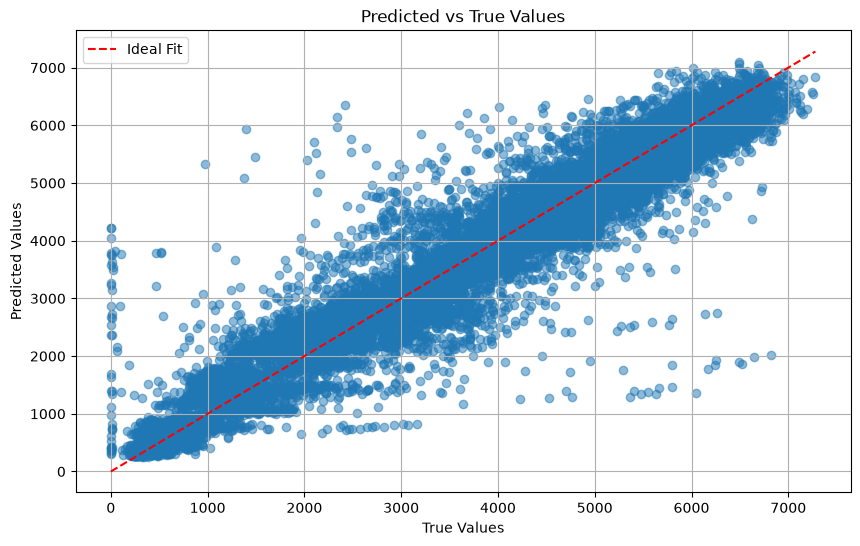

In [69]:
best_lr = 0.0002 # Choose the best learning rate based on the previous graphs

best_poisson_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_model.fit(X, y)
y_pred = best_poisson_model.predict(X)

pred_vs_true_plot(y, y_pred)

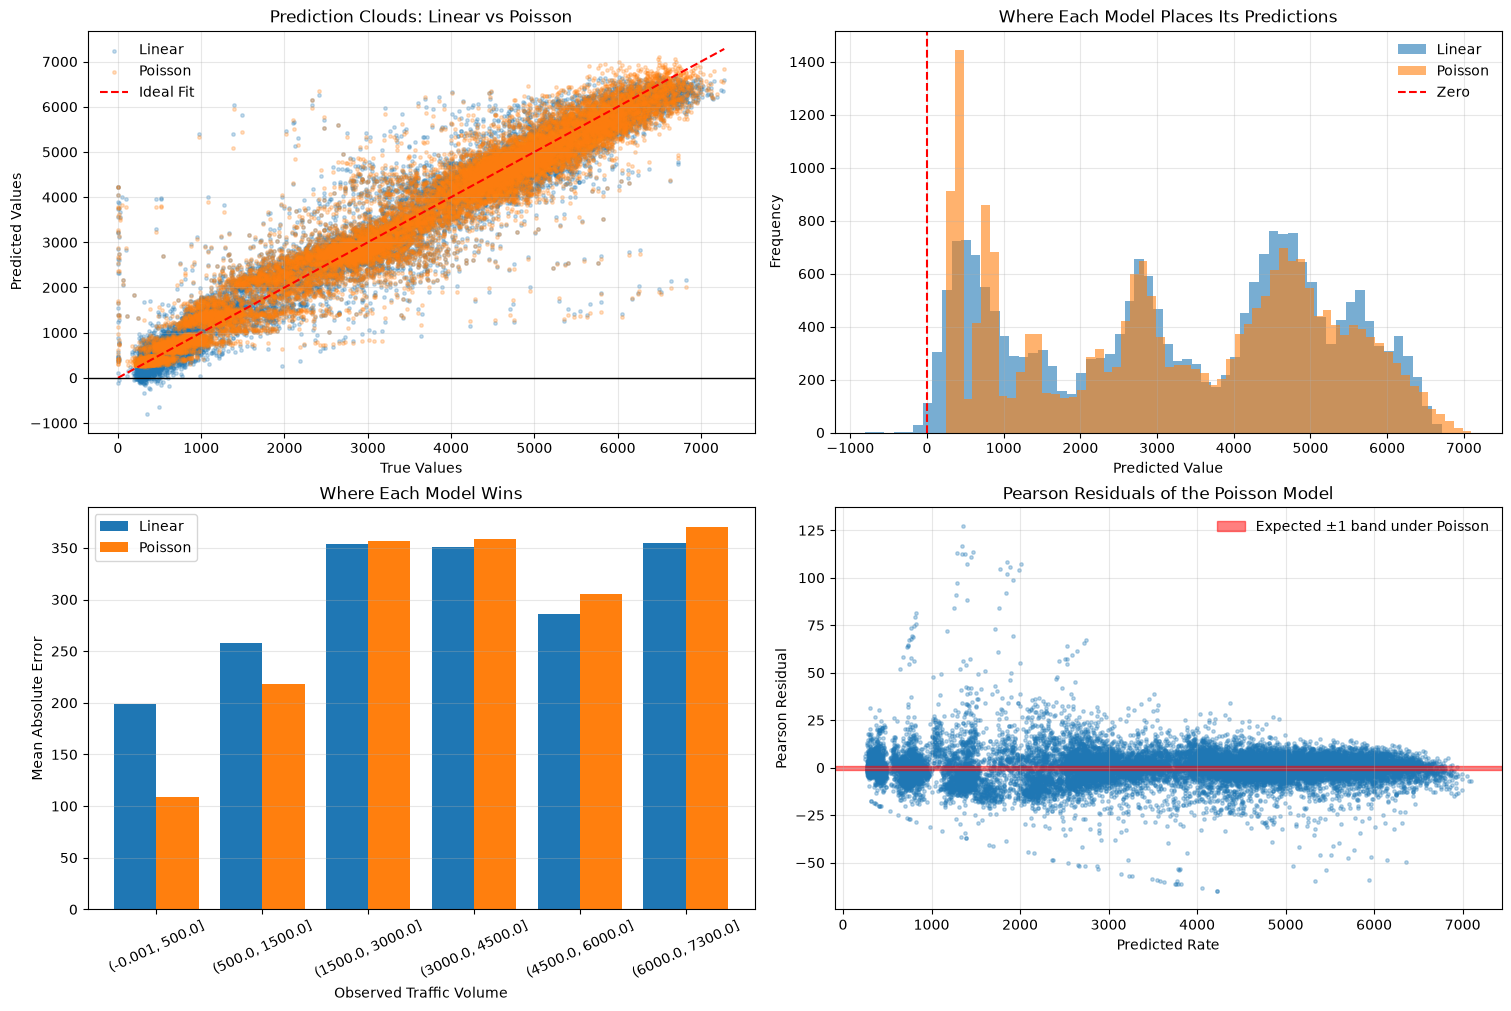

Training set comparison:


,mse,rmse,mae,r2_score,negative_predictions,smallest_prediction,largest_prediction
Linear,212034.6616,460.4722,300.6659,0.9450,74,-807.7682,6711.6600
Polynomial,211481.3818,459.8710,301.2170,0.9452,81,-556.9380,6709.9869
Poisson,212080.2439,460.5217,292.9894,0.9450,0,248.8960,7098.2928


Mean absolute error per observed traffic level:


,Linear,Polynomial,Poisson
level,,,
"(-0.001, 500.0]",198.7,202.5,108.7
"(500.0, 1500.0]",257.4,262.1,218.4
"(1500.0, 3000.0]",354.2,357.9,356.9
"(3000.0, 4500.0]",350.4,348.7,358.4
"(4500.0, 6000.0]",285.5,282.7,305.1
"(6000.0, 7300.0]",354.4,353.0,370.6


Standard deviation of the Pearson residuals: 8.89 (1.0 under a correct Poisson model)
Dispersion statistic: 79.4


In [70]:
# Side by side comparison with the linear model, and the diagnostic that is
# actually meaningful under the Poisson assumption

linear_predictions = best_linear_model.predict(X)
poisson_predictions = y_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# Plot 1: both prediction clouds over the same axes
for name, predictions, color in [
    ("Linear", linear_predictions, "tab:blue"),
    ("Poisson", poisson_predictions, "tab:orange"),
]:
    axes[0, 0].scatter(y, predictions, alpha=0.25, s=6, color=color, label=name)

axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", label="Ideal Fit")
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_xlabel("True Values")
axes[0, 0].set_ylabel("Predicted Values")
axes[0, 0].set_title("Prediction Clouds: Linear vs Poisson")
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=0.3)

# Plot 2: distribution of the predictions, where the negative mass is visible
axes[0, 1].hist(linear_predictions, bins=60, alpha=0.6, label="Linear")
axes[0, 1].hist(poisson_predictions, bins=60, alpha=0.6, label="Poisson")
axes[0, 1].axvline(0, color="red", linestyle="--", label="Zero")

axes[0, 1].set_xlabel("Predicted Value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Where Each Model Places Its Predictions")
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(alpha=0.3)

# Plot 3: mean absolute error per level of the observed value
level = traffic_level(y)
error_by_level = pd.DataFrame(
    {
        "level": level,
        "Linear": np.abs(y - linear_predictions),
        "Poisson": np.abs(y - poisson_predictions),
    }
).groupby("level", observed=True)[["Linear", "Poisson"]].mean()

error_by_level.plot(kind="bar", ax=axes[1, 0], width=0.8)

axes[1, 0].set_xlabel("Observed Traffic Volume")
axes[1, 0].set_ylabel("Mean Absolute Error")
axes[1, 0].set_title("Where Each Model Wins")
axes[1, 0].tick_params(axis="x", labelrotation=25)
axes[1, 0].grid(axis="y", alpha=0.3)

# Plot 4: Pearson residuals. A normal Q-Q plot is not a meaningful diagnostic here,
# as the notebook points out, so we check the variance assumption instead: under a
# correct Poisson model these residuals would have a standard deviation close to 1.
pearson_residuals = (y - poisson_predictions) / np.sqrt(poisson_predictions)

axes[1, 1].scatter(poisson_predictions, pearson_residuals, alpha=0.3, s=6)

# The band where these residuals should lie is a thin strip at this scale, which
# is itself the finding: the observed spread is about nine times wider
axes[1, 1].axhspan(-1, 1, color="red", alpha=0.5, label="Expected ±1 band under Poisson")

axes[1, 1].set_xlabel("Predicted Rate")
axes[1, 1].set_ylabel("Pearson Residual")
axes[1, 1].set_title("Pearson Residuals of the Poisson Model")
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(alpha=0.3)

plt.show()

# The polynomial model from the previous section enters the tables for reference
models_predictions = {
    "Linear": linear_predictions,
    "Polynomial": polynomial_predictions,
    "Poisson": poisson_predictions,
}

full_train_comparison = pd.DataFrame(
    {name: evaluate(y, predictions) for name, predictions in models_predictions.items()}
).T
full_train_comparison["negative_predictions"] = [int((p < 0).sum()) for p in models_predictions.values()]
full_train_comparison["smallest_prediction"] = [p.min() for p in models_predictions.values()]
full_train_comparison["largest_prediction"] = [p.max() for p in models_predictions.values()]

print("Training set comparison:")
display(full_train_comparison.round(4))

print("Mean absolute error per observed traffic level:")
display(
    pd.DataFrame(
        {
            "level": level,
            **{name: np.abs(y - predictions) for name, predictions in models_predictions.items()},
        }
    )
    .groupby("level", observed=True)[list(models_predictions)]
    .mean()
    .round(1)
)

print("Standard deviation of the Pearson residuals: {:.2f} (1.0 under a correct Poisson model)".format(
    pearson_residuals.std()
))
print("Dispersion statistic: {:.1f}".format(
    np.sum(pearson_residuals**2) / (len(y) - X.shape[1] - 1)
))

> **Question:**
>
> Compare the prediction plots obtained with the **Linear**, **Polynomial**, and
> **Poisson** models.
>
> - Does the Poisson model change the overall shape of the prediction cloud?
> - Do the predictions appear more consistent with the count nature of the data?
> - Are extreme values predicted differently?
>
> Based on the visualization, what differences arise from changing the
> probabilistic assumption of the model?

**Answer:**

Sim, a mudança da premissa distribucional altera visivelmente o formato da nuvem de predições, o que não aconteceu com a expansão polinomial. As nuvens dos modelos linear e polinomial são praticamente sobrepostas, com predições de correlação 0.99978, ambas simétricas em torno da reta ideal e estendendo-se abaixo de zero. No modelo de Poisson a nuvem é comprimida na região de volumes baixos e mais espalhada na região de volumes altos. Isso decorre diretamente da ligação logarítmica, que torna a escala do erro proporcional ao nível previsto em vez de constante.

As predições passam a ser coerentes com a natureza de contagem do alvo. A regressão linear coloca 74 predições abaixo de zero, chegando a −807.8 veículos/hora, e a polinomial 81, chegando a −556.9, valores impossíveis para uma contagem. O modelo de Poisson não produz nenhuma, com predição mínima de 248.9, e isso não é consequência do ajuste, mas da própria construção do modelo, já que $\lambda = \exp(x^T\beta)$ é estritamente positivo para qualquer valor dos parâmetros. A flexibilidade adicional do polinômio não resolve esse problema, pois a predição continua sendo uma combinação linear sem restrição de sinal.

Os extremos são tratados de forma diferente nas duas pontas. Na faixa de menor volume, o erro absoluto médio é de 198.7 na linear e 202.5 na polinomial, e cai para 108.7 na de Poisson, porque ela concentra suas predições em uma faixa estreita e positiva quando o nível esperado é baixo. Na outra ponta, o modelo de Poisson alcança predições de até 7098, contra 6712 da linear e 6710 da polinomial, acompanhando melhor os picos mais altos, embora ao custo de um erro ligeiramente maior nas faixas intermediárias.

O diagnóstico de resíduos também muda de natureza. Como observado no enunciado, comparar os resíduos com uma distribuição normal deixa de fazer sentido aqui, já que o modelo não assume erro aditivo Gaussiano. O diagnóstico apropriado é o resíduo de Pearson, $(y - \lambda)/\sqrt{\lambda}$, que sob um modelo de Poisson correto teria desvio-padrão próximo de 1. O valor observado é 8.89, com estatística de dispersão de 79.4, evidenciando que a variância real é muito maior do que a distribuição assume. Dessa forma, a troca de premissa corrigiu o suporte da predição e a forma como a variância escala com a média, algo que aumentar a capacidade não fez, mas não a magnitude dessa variância, que continua mal descrita.

---
### **Residual Diagnostics for Poisson Regression**

In the previous sections we used a **Q–Q plot** to evaluate whether the
residuals followed a **Normal distribution**. This diagnostic was meaningful
because linear regression was derived under the assumption that the error term
follows a Gaussian distribution,

$$\epsilon \sim \mathcal{N}(0,\sigma^2).$$

Under this assumption, if the model is well specified, the residual

$$r_i = y_i - \hat{y}_i,$$
should also resemble a Normal distribution.

The Q–Q plot therefore allowed us to visually verify whether this assumption was
reasonable.
However, this reasoning no longer applies to **Poisson regression**, as the
target $y$ now is assumed to be drawn from a Poisson distribution with

$$y \sim \text{Poisson}(\lambda), \qquad \lambda = \exp(x^T\beta).$$

Because of this, the residuals are **not expected to follow a Normal
distribution**, even if the model is correct.
A Q–Q plot comparing them to a Normal distribution therefore does not test a
relevant assumption.


---
### **Polynomial Poisson Regression**

As we observed an increased performance by introducing polynomial
features, allowing the model to capture nonlinear relationships between the
predictors and the target.
The same idea can be applied to **Poisson regression**.

Instead of changing the probabilistic model, we only change the
**feature representation**. The Poisson model still assumes that the
expected count follows an exponential transformation of a linear
predictor,

$$\lambda = \exp(x^T\beta).$$
with $x$ now containing polynomial terms.

Continue exploring Poisson models with more complex relationships, find the best
degrees and learning rates.


Validation R² per degree and learning rate (NaN means an unstable run):


learning_rate,0.00002,0.00005,0.00010,0.00020,0.00030
degree,,,,,
1,0.9173,0.9261,0.9283,0.9288,0.9289
2,0.9174,0.9267,0.9293,0.9299,NaN
3,0.9165,0.9257,NaN,NaN,NaN
4,0.9169,NaN,NaN,NaN,NaN



Summary per degree (best stable learning rate on the validation set):


,columns,step_size_limit,learning_rate,train_r2,val_r2,val_mae,largest_stable_lr
degree,,,,,,,
1,78,0.000348,0.00030,0.947466,0.928907,348.551878,0.00030
2,84,0.000185,0.00020,0.947699,0.929947,346.045201,0.00020
3,94,0.000083,0.00005,0.946448,0.925682,365.175107,0.00005
4,109,0.000045,0.00002,0.939883,0.916931,400.021931,0.00002


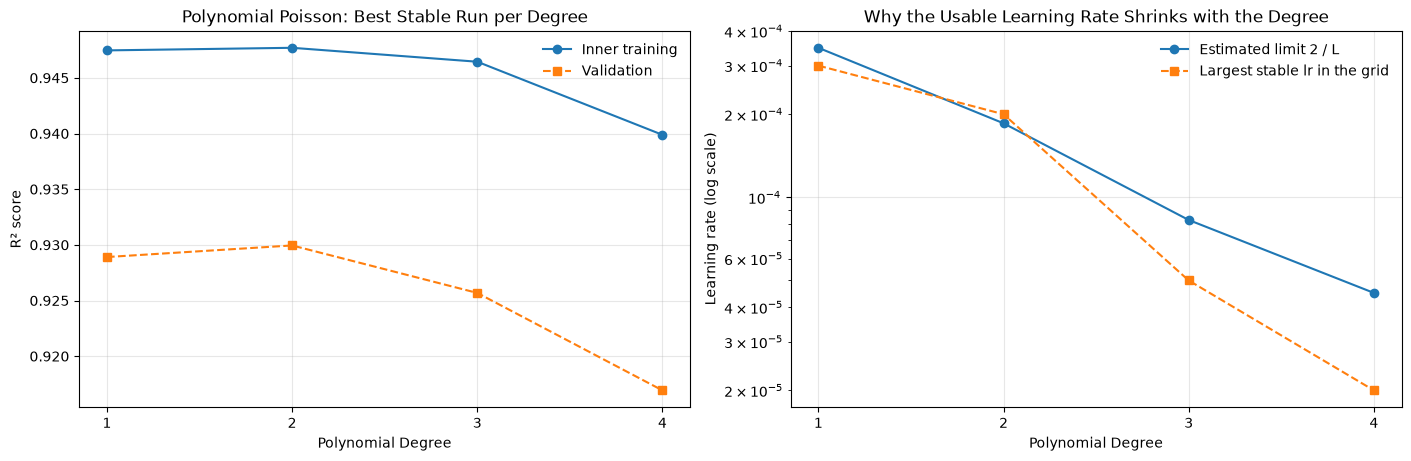

In [71]:
# Implement and train the polynomial poisson regression models here using the
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

# The same protocol as the polynomial linear models: expansion of the continuous
# block, re-standardization with inner training statistics (build_polynomial),
# selection on the validation set, and a run is called stable only when the
# objective never increases.
poisson_degrees = [1, 2, 3, 4]
poisson_poly_lrs = [2e-5, 5e-5, 1e-4, 2e-4, 3e-4]

poisson_poly_search = []
step_size_limits = []

for degree in poisson_degrees:
    poly_inner, poly_val = build_polynomial(X_inner, X_val, degree)

    # Gradient descent on a smooth objective is stable for steps below 2 / L, where
    # L is the largest eigenvalue of the Hessian. For the Poisson objective the
    # Hessian is X^T diag(lambda) X / n, so at the initial point (lambda = mean(y))
    # L is mean(y) times the largest eigenvalue of X^T X / n. It grows with the
    # collinearity of the polynomial terms, and it carries the scale of the counts.
    design = np.hstack([np.ones((len(poly_inner), 1)), poly_inner])
    curvature = y_inner.mean() * np.linalg.eigvalsh(design.T @ design / len(design)).max()
    step_size_limits.append({"degree": degree, "columns": poly_inner.shape[1], "step_size_limit": 2 / curvature})

    for learning_rate in poisson_poly_lrs:
        model = PoissonRegression(learning_rate=learning_rate, n_iterations=8000)
        model.fit(poly_inner, y_inner)

        overshooting_steps = increases_in(model)
        stable_run = overshooting_steps == 0

        train_predictions = model.predict(poly_inner)
        val_predictions = model.predict(poly_val)

        poisson_poly_search.append(
            {
                "degree": degree,
                "learning_rate": learning_rate,
                "overshooting_steps": overshooting_steps,
                "train_r2": r2_score(y_inner, train_predictions) if stable_run else np.nan,
                "val_r2": r2_score(y_val, val_predictions) if stable_run else np.nan,
                "val_mae": mae(y_val, val_predictions) if stable_run else np.nan,
            }
        )

poisson_poly_search = pd.DataFrame(poisson_poly_search)
step_size_limits = pd.DataFrame(step_size_limits).set_index("degree")

print("Validation R² per degree and learning rate (NaN means an unstable run):")
display(poisson_poly_search.pivot(index="degree", columns="learning_rate", values="val_r2").round(4))

stable_runs = poisson_poly_search.dropna()
best_poisson_per_degree = stable_runs.loc[stable_runs.groupby("degree")["val_r2"].idxmax()].set_index("degree")

poisson_summary = step_size_limits.join(best_poisson_per_degree)
poisson_summary["largest_stable_lr"] = stable_runs.groupby("degree")["learning_rate"].max()

print("\nSummary per degree (best stable learning rate on the validation set):")
display(poisson_summary.drop(columns="overshooting_steps").round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(poisson_summary.index, poisson_summary["train_r2"], marker="o", label="Inner training")
axes[0].plot(poisson_summary.index, poisson_summary["val_r2"], marker="s", linestyle="--", label="Validation")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("R² score")
axes[0].set_title("Polynomial Poisson: Best Stable Run per Degree")
axes[0].set_xticks(poisson_degrees)
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

# The theoretical bound against what was observed in the sweep
axes[1].plot(poisson_summary.index, poisson_summary["step_size_limit"], marker="o", label="Estimated limit 2 / L")
axes[1].plot(poisson_summary.index, poisson_summary["largest_stable_lr"], marker="s", linestyle="--", label="Largest stable lr in the grid")
axes[1].set_yscale("log")
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("Learning rate (log scale)")
axes[1].set_title("Why the Usable Learning Rate Shrinks with the Degree")
axes[1].set_xticks(poisson_degrees)
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

plt.show()

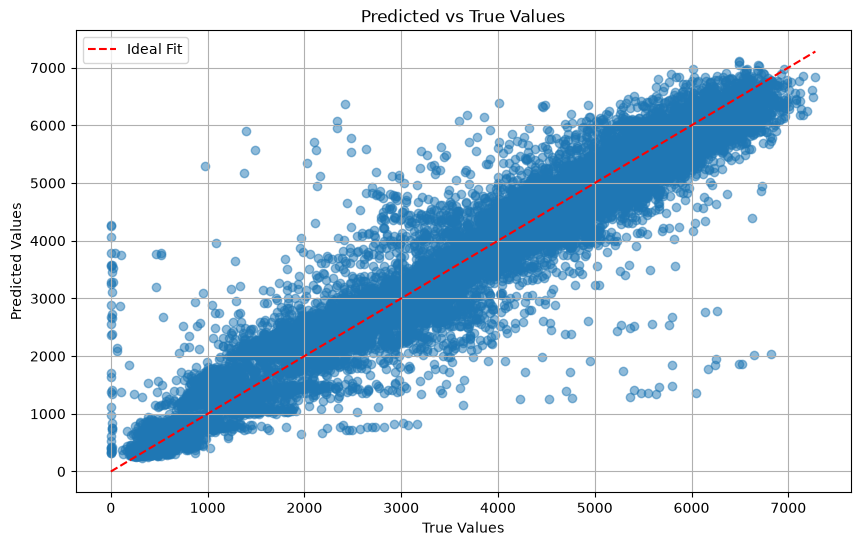

In [72]:
best_lr = 0.0002 # Choose the best learning rate based on the previous graphs
best_degree = 2 # Choose the best degree based on experimentation with different degrees and analyzing the results

# As in the polynomial linear model, the expanded block is standardized again, with
# statistics taken from the training matrix itself, instead of using the raw
# polynomial_expansion output
X_poly, _ = build_polynomial(X, X, best_degree)

best_poisson_poly_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_poly_model.fit(X_poly, y)
y_pred = best_poisson_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

Iterations in which the objective increased in the final fit: 0


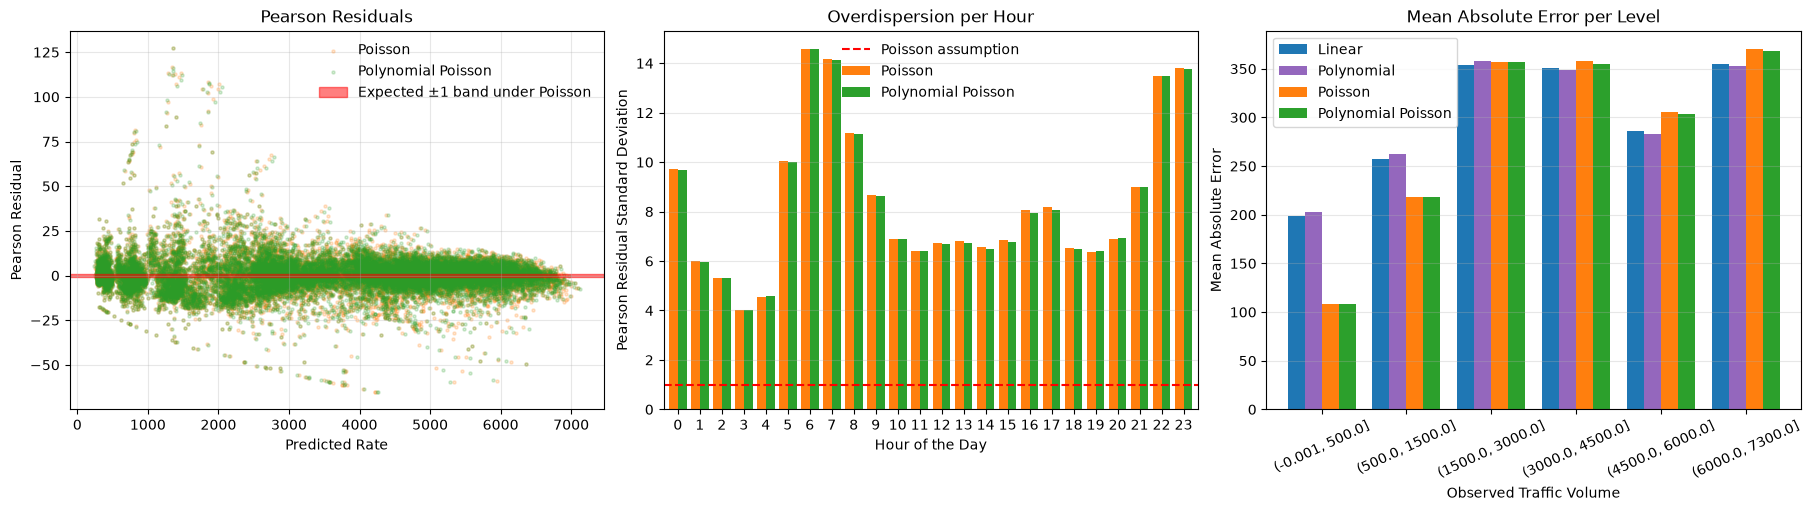

Training set comparison:


,mse,rmse,mae,r2_score,residual_kurtosis,hourly_residual_std_ratio,pearson_std,dispersion
Linear,212034.6616,460.4722,300.6659,0.9450,16.2188,3.6883,NaN,NaN
Polynomial,211481.3818,459.8710,301.2170,0.9452,16.0123,3.6017,NaN,NaN
Poisson,212080.2439,460.5217,292.9894,0.9450,16.0713,9.4454,8.8948,79.4153
Polynomial Poisson,210192.1161,458.4671,291.5073,0.9455,16.1380,9.4206,8.8684,78.9662


Correlation between the Poisson and polynomial Poisson predictions: 0.99971
Mean absolute difference between them: 28.8 vehicles/hour

Mean absolute error per observed traffic level:


,Linear,Polynomial,Poisson,Polynomial Poisson
level,,,,
"(-0.001, 500.0]",198.7,202.5,108.7,108.1
"(500.0, 1500.0]",257.4,262.1,218.4,217.9
"(1500.0, 3000.0]",354.2,357.9,356.9,356.5
"(3000.0, 4500.0]",350.4,348.7,358.4,355.4
"(4500.0, 6000.0]",285.5,282.7,305.1,303.4
"(6000.0, 7300.0]",354.4,353.0,370.6,368.6


Standard deviation of the Pearson residuals per hour, smallest and largest, and the hour where each occurs:


,Poisson,Polynomial Poisson
min,4.02,4.02
idxmin,3.00,3.00
max,14.59,14.57
idxmax,6.00,6.00


In [73]:
# Residual structure of the two Poisson models, next to the linear counterparts,
# to check whether the expansion changed the residuals in the same way

poisson_poly_predictions = y_pred
print("Iterations in which the objective increased in the final fit:", increases_in(best_poisson_poly_model))

pearson_by_model = pd.DataFrame(
    {
        "hr": train_df["hr"].to_numpy(),
        "Poisson": (y - poisson_predictions) / np.sqrt(poisson_predictions),
        "Polynomial Poisson": (y - poisson_poly_predictions) / np.sqrt(poisson_poly_predictions),
    }
)
pearson_spread = pearson_by_model.groupby("hr")[["Poisson", "Polynomial Poisson"]].std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Plot 1: Pearson residuals of both Poisson models against the predicted rate
for name, predictions, color in [
    ("Poisson", poisson_predictions, "tab:orange"),
    ("Polynomial Poisson", poisson_poly_predictions, "tab:green"),
]:
    axes[0].scatter(predictions, pearson_by_model[name], alpha=0.2, s=5, color=color, label=name)
axes[0].axhspan(-1, 1, color="red", alpha=0.5, label="Expected ±1 band under Poisson")
axes[0].set_xlabel("Predicted Rate")
axes[0].set_ylabel("Pearson Residual")
axes[0].set_title("Pearson Residuals")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

# Plot 2: how the dispersion of the Pearson residuals varies along the day
pearson_spread.plot(kind="bar", ax=axes[1], width=0.8, color=["tab:orange", "tab:green"])
axes[1].axhline(1, color="red", linestyle="--", label="Poisson assumption")
axes[1].set_xlabel("Hour of the Day")
axes[1].set_ylabel("Pearson Residual Standard Deviation")
axes[1].set_title("Overdispersion per Hour")
axes[1].tick_params(axis="x", labelrotation=0)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.3)

# Plot 3: mean absolute error per observed level for the four models
four_models = {
    "Linear": linear_predictions,
    "Polynomial": polynomial_predictions,
    "Poisson": poisson_predictions,
    "Polynomial Poisson": poisson_poly_predictions,
}
level = traffic_level(y)
error_by_level_four = pd.DataFrame(
    {"level": level, **{name: np.abs(y - predictions) for name, predictions in four_models.items()}}
).groupby("level", observed=True)[list(four_models)].mean()

error_by_level_four.plot(kind="bar", ax=axes[2], width=0.8, color=["tab:blue", "tab:purple", "tab:orange", "tab:green"])
axes[2].set_xlabel("Observed Traffic Volume")
axes[2].set_ylabel("Mean Absolute Error")
axes[2].set_title("Mean Absolute Error per Level")
axes[2].tick_params(axis="x", labelrotation=25)
axes[2].grid(axis="y", alpha=0.3)

plt.show()


# Effect of the expansion on each family: training set metrics and residual shape
def residual_profile(predictions: NDArray[np.float64], n_columns: int, poisson: bool) -> dict[str, float]:
    profile = evaluate(y, predictions)
    residuals = y - predictions
    hourly_std = pd.Series(residuals).groupby(train_df["hr"].to_numpy()).std()

    profile["residual_kurtosis"] = pd.Series(residuals).kurt()
    profile["hourly_residual_std_ratio"] = hourly_std.max() / hourly_std.min()
    profile["pearson_std"] = np.nan
    profile["dispersion"] = np.nan

    if poisson:
        pearson = residuals / np.sqrt(predictions)
        profile["pearson_std"] = pearson.std()
        profile["dispersion"] = np.sum(pearson**2) / (len(y) - n_columns - 1)
    return profile


profiles = pd.DataFrame(
    {
        "Linear": residual_profile(linear_predictions, X.shape[1], poisson=False),
        "Polynomial": residual_profile(polynomial_predictions, X_poly.shape[1], poisson=False),
        "Poisson": residual_profile(poisson_predictions, X.shape[1], poisson=True),
        "Polynomial Poisson": residual_profile(poisson_poly_predictions, X_poly.shape[1], poisson=True),
    }
).T

print("Training set comparison:")
display(profiles.round(4))

print("Correlation between the Poisson and polynomial Poisson predictions: {:.5f}".format(
    np.corrcoef(poisson_predictions, poisson_poly_predictions)[0, 1]
))
print("Mean absolute difference between them: {:.1f} vehicles/hour".format(
    np.mean(np.abs(poisson_predictions - poisson_poly_predictions))
))
print()

print("Mean absolute error per observed traffic level:")
display(error_by_level_four.round(1))

print("Standard deviation of the Pearson residuals per hour, smallest and largest, and the hour where each occurs:")
display(pearson_spread.agg(["min", "idxmin", "max", "idxmax"]).round(2))

> **Question:**
>
> Compare the residual structure of the **Poisson** and
> **Polynomial Poisson** models.
>
> Was the improvement similar to the Linear Regression counterparts?
> How are they different?

**Answer:**

A estrutura dos resíduos praticamente não muda com a expansão. As predições dos modelos de Poisson e Poisson polinomial têm correlação de 0.99971 e diferem, em média, 28.8 veículos/hora. O desvio-padrão dos resíduos de Pearson passa de 8.89 para 8.87 e a estatística de dispersão de 79.4 para 79.0, de modo que a superdispersão permanece intacta. Ela também não é uniforme ao longo do dia: o desvio-padrão dos resíduos de Pearson por hora varia de 4.02 às 3h a 14.59 às 6h nos dois modelos. Ou seja, a variância não é igual à média, como a Poisson assume, nem um múltiplo constante dela, e termos polinomiais nas features contínuas não alteram essa propriedade, que é da distribuição e não da média condicional. A curtose dos resíduos também se mantém, de 16.07 para 16.14.

Em desempenho, a melhora teve magnitude semelhante à dos modelos lineares, embora ligeiramente maior e mais consistente. Na validação, o grau 2 leva o $R^2$ de 0.9289 para 0.9299, um ganho de 0.0010 contra 0.0005 na regressão linear. No treinamento completo, o $R^2$ passa de 0.9450 para 0.9455 e o erro absoluto médio de 293.0 para 291.5, enquanto na regressão linear o erro absoluto médio chegou a piorar. A diferença mais clara está na distribuição do ganho: na Poisson polinomial o erro absoluto médio cai nas seis faixas de volume, ainda que pouco, enquanto na linear a expansão piorou as faixas mais baixas, de 198.7 para 202.5 abaixo de 500 veículos/hora. Isso é coerente com a ligação logarítmica, pois os termos polinomiais entram no expoente e atuam de forma multiplicativa, com efeito proporcional ao nível previsto, em vez de somar a mesma quantidade em horários de volumes muito diferentes.

A escolha dos hiperparâmetros, entretanto, é mais delicada que no caso linear. A maior taxa de aprendizado estável cai de 3e-4 no grau 1 para 2e-4, 5e-5 e 2e-5 nos graus 2 a 4, acompanhando a estimativa teórica $2/L$, em que $L$ é o maior autovalor da hessiana $X^T \mathrm{diag}(\lambda) X / n$ no ponto inicial. Como essa hessiana carrega a escala das contagens, os passos são milhares de vezes menores que os da regressão linear, e nos graus 3 e 4 as 8000 iterações não bastam para convergir, com $R^2$ de treinamento de 0.9464 e 0.9399. Diferentemente do caso linear, não há solução fechada para separar o efeito da capacidade do efeito da otimização, de modo que a piora nesses graus não pode ser atribuída apenas a sobreajuste. Vale notar ainda que, no grau 1, a taxa 3e-4, ausente da busca anterior, fica praticamente empatada com a escolhida lá, 0.9289 contra 0.9288.

Escolhemos o grau 2 com taxa de aprendizado 2e-4, melhor na validação com $R^2$ de 0.9299 e erro absoluto médio de 346.0. Assim como no caso linear, o ganho é pequeno e confirma a conclusão anterior: a expansão ajusta marginalmente a média condicional, mas a principal limitação do modelo está na variância assumida.

---
## **Final Model Comparison**


Until this point, all analysis and decisions were made using only the **training data**.  
The **test dataset** has remained untouched so that it can provide an unbiased
evaluation of the final models.

This is important in machine learning, as our job is not to train a model that can
copy the behavior in data, but to generalize to unseen observations.
The decisions made to improve the performance based only on training data may or
may not reflect in the test data, indicating an under- or overfitting.

(1.0 points) Before using the test dataset, look at all your decisions and assumptions done
on each model and discuss them.
In real life, this would be the last step before the deployment of our models.

> **Question:**
>
> Revisiting all the models you have trained, what are the main differences between them in performance and assumptions?
> 
> If you could select only one, based on your analysis, which one would you choose and why?
> Also discuss about its possible limitations, what it doesn't solve?
>
> How do you think it will perform on unseen data?

**Answer:**

Os quatro modelos usam a mesma matriz de features e diferem em dois eixos: a forma da média condicional, linear ou com termos polinomiais de grau 2 nas variáveis contínuas, e a distribuição assumida para o alvo, Gaussiana com variância constante ou Poisson com ligação logarítmica. Em desempenho agregado as diferenças são pequenas. Na validação, o $R^2$ fica entre 0.9288 e 0.9305 e o erro absoluto médio entre 346.0 e 349.3 veículos/hora, e no treinamento completo o $R^2$ fica entre 0.9450 e 0.9455. Nas premissas, entretanto, as diferenças são grandes. Os modelos Gaussianos produzem predições negativas em 0.35% e 0.38% das horas de treinamento e tratam com a mesma gravidade erros em horários de 726 e de 4752 veículos/hora. Os de Poisson, por outro lado, garantem predições positivas, tornam os efeitos multiplicativos e reduzem em cerca de 45% o erro nas horas de menor volume. A expansão polinomial mudou pouco em ambas as famílias.

Entre os modelos avaliados, escolheríamos a regressão de Poisson polinomial de grau 2. Ela apresenta o menor MAE de validação, aproximadamente 346 veículos/hora, com $R^2=0.9299$, muito próximo do melhor $R^2$ observado. Além disso, suas previsões são coerentes com a natureza de contagem do target. A vantagem em relação à Poisson sem expansão é pequena, portanto não há evidência de que os termos polinomiais produzam uma melhora substancial, mas essa configuração apresentou o melhor compromisso entre desempenho e adequação ao problema.

A principal limitação é que variância observada é cerca de 79 vezes a assumida e varia ao longo do dia, de modo que o modelo subestima a incerteza das próprias predições. O modelo também não utiliza o tráfego das horas anteriores e, portanto, não representa explicitamente dependência temporal. Embora possua uma variável "holiday", todos os feriados são tratados da mesma forma, sem distinguir eventos específicos, e períodos anômalos como 2016-07-23 permanecem no treinamento. Além disso, não foram incluídas interações entre condições meteorológicas categóricas e horário, de modo que um determinado tipo de clima possui o mesmo efeito relativo ao longo do dia. Devido ao problema da variabilidade dos dados ser maior do que a dispersão prevista por uma distribuição Poisson simples, uma distribuição capaz de acomodar superdispersão, como a binomial negativa, seria uma alternativa a investigar.

Para dados futuros, esperaríamos inicialmente um desempenho próximo ao observado na validação, com $R^2$ em torno de 0.93 e MAE próximo de 350 veículos/hora, embora exista incerteza nessa estimativa. Em particular, há um risco relacionado a 2018, já que o treinamento completo contém apenas janeiro e parte de fevereiro desse ano, enquanto o treinamento interno usado na validação não continha 2018. Consequentemente, o efeito específico de 2018 aprendido pelo modelo final não foi efetivamente avaliado durante a seleção de hiperparâmetros. Se o nível de tráfego observado no início de 2018 não for representativo do restante do ano, esse efeito pode introduzir um deslocamento nas previsões do período de teste.

---

(0.5 points) Now evaluate all trained models on the **test dataset** using the same metrics
used previously.
Compute the predictions and compare their performance.

In [74]:
# Comparison code here, make sure you have the final models

# The four final models, all retrained on the full training set with the
# hyperparameters chosen on the validation set, and the polynomial degree each uses
final_models = {
    "Linear": (best_linear_model, 1),
    "Polynomial": (best_poly_model, 2),
    "Poisson": (best_poisson_model, 1),
    "Polynomial Poisson": (best_poisson_poly_model, 2),
}


def design_matrix(X_apply: NDArray[np.float64], degree: int) -> NDArray[np.float64]:
    """Builds the input of a final model, expanding with full training statistics."""
    if degree == 1:
        return X_apply
    return build_polynomial(X, X_apply, degree)[1]


def negative_share(predictions: NDArray[np.float64]) -> float:
    return 100 * float(np.mean(predictions < 0))


# Validation scores of the selected configurations, taken from the searches above
validation_scores = {
    "Linear": summary.loc[1, ["val_r2", "val_mae"]],
    "Polynomial": summary.loc[2, ["val_r2", "val_mae"]],
    "Poisson": poisson_search.loc[0.0002, ["val_r2", "val_mae"]],
    "Polynomial Poisson": poisson_summary.loc[2, ["val_r2", "val_mae"]],
}

model_comparison = []
for name, (model, degree) in final_models.items():
    train_predictions = model.predict(design_matrix(X, degree))
    train_scores = evaluate(y, train_predictions)

    model_comparison.append(
        {
            "model": name,
            "columns": design_matrix(X, degree).shape[1],
            "train_r2": train_scores["r2_score"],
            "train_mae": train_scores["mae"],
            "val_r2": validation_scores[name]["val_r2"],
            "val_mae": validation_scores[name]["val_mae"],
            "train_negative_pct": negative_share(train_predictions),
        }
    )

model_comparison = pd.DataFrame(model_comparison).set_index("model")

print("Final models before touching the test set:")
display(model_comparison.round(4))

Final models before touching the test set:


,columns,train_r2,train_mae,val_r2,val_mae,train_negative_pct
model,,,,,,
Linear,79,0.9450,300.6659,0.9300,347.2791,0.3468
Polynomial,85,0.9452,301.2170,0.9305,346.4903,0.3796
Poisson,79,0.9450,292.9894,0.9288,349.3084,0.0000
Polynomial Poisson,85,0.9455,291.5073,0.9299,346.0452,0.0000


Test set performance:


,mse,rmse,mae,r2_score,negative_pct,mean_residual,val_r2,val_mae
Linear,163124.3819,403.8866,270.1840,0.9587,0.1499,24.1649,0.9300,347.2791
Polynomial,162146.8001,402.6746,269.9413,0.9589,0.1124,13.9677,0.9305,346.4903
Poisson,164794.3794,405.9487,261.6372,0.9582,0.0000,27.8169,0.9288,349.3084
Polynomial Poisson,162388.0533,402.9740,258.2188,0.9589,0.0000,10.9553,0.9299,346.0452


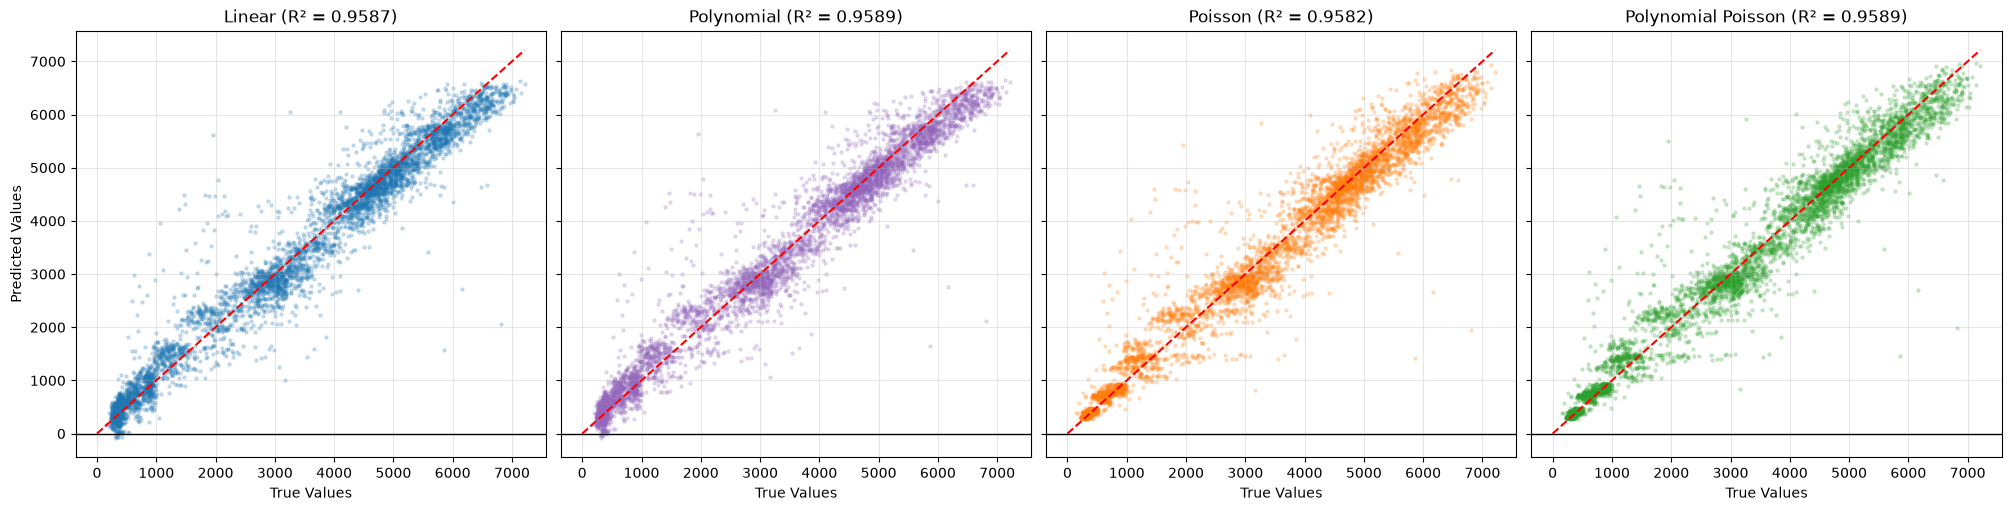

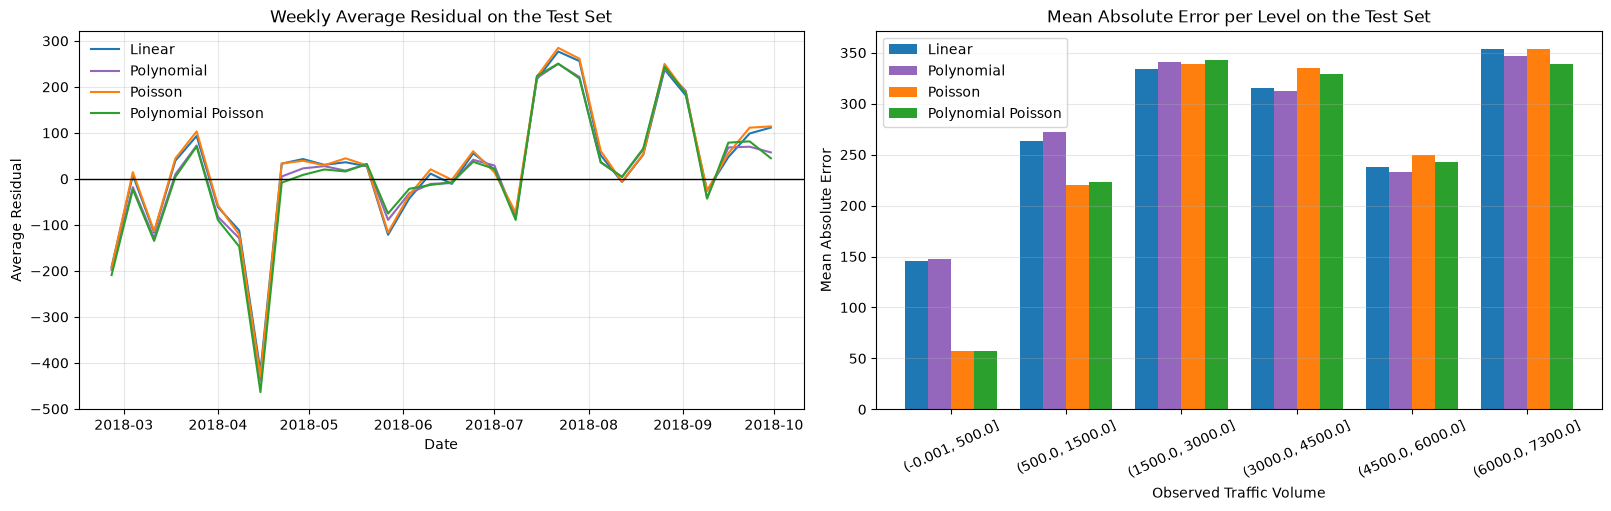

Mean absolute error per observed traffic level:


,Linear,Polynomial,Poisson,Polynomial Poisson
level,,,,
"(-0.001, 500.0]",145.2,147.7,57.0,57.4
"(500.0, 1500.0]",263.5,272.4,220.1,222.7
"(1500.0, 3000.0]",334.4,340.4,339.0,343.2
"(3000.0, 4500.0]",315.8,312.4,334.9,329.0
"(4500.0, 6000.0]",237.7,232.7,249.4,242.5
"(6000.0, 7300.0]",353.9,347.0,353.2,338.5


Training period: 2015-06-11 to 2018-02-19
Test period    : 2018-02-19 to 2018-09-30
Mean traffic volume -> training: 3277.7, test: 3358.9
Years in the test set: {3: 5336}
Hours with snow_1h above zero in the test set: 0
Share of holiday hours -> training: 3.3%, test: 1.8%
Hours below 100 vehicles, such as sensor failures -> training: 46, test: 0

Mean absolute error of the polynomial Poisson model per month:


,1,2,3,4,5,6,7,8,9,10,11,12
train,311.4,289.2,254.9,265.4,244.4,256.7,317.2,266.6,262.1,296.7,335.6,362.9
test,NaN,271.4,268.3,341.1,224.3,196.9,292.3,252.4,228.0,NaN,NaN,NaN


Mean absolute error in the training set -> February to September: 272.1, October to January: 326.3
Weeks with the largest average residual in absolute value (polynomial Poisson):


...

,Linear,Polynomial,Poisson,Polynomial Poisson
mnth,,,,
2,-126.2,-141.2,-128.0,-153.2
3,-5.0,-26.1,0.4,-31.1
4,-110.4,-130.1,-115.3,-146.4
5,-26.4,-17.5,-22.3,-14.1
6,20.2,11.6,27.0,10.9
7,172.9,155.7,177.6,153.9
8,92.4,95.5,97.7,95.7
9,66.1,50.3,71.8,51.8


Mean traffic volume in January and February, per year (training set):


yr,1,2,3
traffic_volume,3108.1,3246.3,3167.8


Mean traffic volume per month, test set against the training set:


mnth,2,3,4,5,6,7,8,9
train,3292.1,3464.4,3445.1,3370.6,3448.5,3114.9,3368.1,3328.9
test,3265.3,3446.9,3297.2,3394.5,3422.5,3252.5,3436.4,3289.3


In [75]:
X_test, y_test = preprocess_data(test_df, reference_df=train_df)

# You can create plots comparing the predictions of the different models, e.g., predicted vs true values for each model, residual plots, etc.
# Measure the performance of each model using the implemented metrics and compare them in a table or bar plot.
# Feel free to explore other ways to compare the models and analyze their predictions.

model_colors = {
    "Linear": "tab:blue",
    "Polynomial": "tab:purple",
    "Poisson": "tab:orange",
    "Polynomial Poisson": "tab:green",
}

test_predictions = {
    name: model.predict(design_matrix(X_test, degree))
    for name, (model, degree) in final_models.items()
}

# Metrics on the test set, next to the validation scores used to choose the models
test_comparison = pd.DataFrame(
    {name: evaluate(y_test, predictions) for name, predictions in test_predictions.items()}
).T
test_comparison["negative_pct"] = [negative_share(p) for p in test_predictions.values()]
test_comparison["mean_residual"] = [np.mean(y_test - p) for p in test_predictions.values()]
test_comparison["val_r2"] = model_comparison["val_r2"]
test_comparison["val_mae"] = model_comparison["val_mae"]

print("Test set performance:")
display(test_comparison.round(4))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True, sharey=True)

# Plot 1: predicted vs observed for each model
for ax, (name, predictions) in zip(axes, test_predictions.items()):
    ax.scatter(y_test, predictions, alpha=0.2, s=5, color=model_colors[name])
    ax.plot([0, y_test.max()], [0, y_test.max()], color="red", linestyle="--")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("{} (R² = {:.4f})".format(name, r2_score(y_test, predictions)))
    ax.set_xlabel("True Values")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Predicted Values")

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# Plot 2: average residual per week, to see whether the error drifts over time
for name, predictions in test_predictions.items():
    weekly_residual = pd.Series(y_test - predictions, index=test_df["date"]).resample("W").mean()
    axes[0].plot(weekly_residual.index, weekly_residual.values, label=name, color=model_colors[name])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average Residual")
axes[0].set_title("Weekly Average Residual on the Test Set")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

# Plot 3: mean absolute error per observed traffic level
test_level = traffic_level(y_test)
test_error_by_level = pd.DataFrame(
    {"level": test_level, **{name: np.abs(y_test - p) for name, p in test_predictions.items()}}
).groupby("level", observed=True)[list(test_predictions)].mean()

test_error_by_level.plot(kind="bar", ax=axes[1], width=0.8, color=list(model_colors.values()))
axes[1].set_xlabel("Observed Traffic Volume")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("Mean Absolute Error per Level on the Test Set")
axes[1].tick_params(axis="x", labelrotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.show()

print("Mean absolute error per observed traffic level:")
display(test_error_by_level.round(1))

# How the test period differs from the training period
print("Training period: {} to {}".format(train_df["date"].min().date(), train_df["date"].max().date()))
print("Test period    : {} to {}".format(test_df["date"].min().date(), test_df["date"].max().date()))
print("Mean traffic volume -> training: {:.1f}, test: {:.1f}".format(train_df["traffic_volume"].mean(), test_df["traffic_volume"].mean()))
print("Years in the test set:", test_df["yr"].value_counts().to_dict())
print("Hours with snow_1h above zero in the test set:", int((test_df["snow_1h"] > 0).sum()))
print("Share of holiday hours -> training: {:.1f}%, test: {:.1f}%".format(
    100 * train_df["holiday"].mean(), 100 * test_df["holiday"].mean()
))
print("Hours below 100 vehicles, such as sensor failures -> training: {}, test: {}".format(
    int((y < 100).sum()), int((y_test < 100).sum())
))
print()

# Error of the chosen model per month, in the training set (in-sample) and in the
# test set, to check whether the months covered by the test are simply easier
chosen_model, chosen_degree = final_models["Polynomial Poisson"]
chosen_train_predictions = chosen_model.predict(design_matrix(X, chosen_degree))
print("Mean absolute error of the polynomial Poisson model per month:")
display(
    pd.DataFrame(
        {
            "train": pd.Series(np.abs(y - chosen_train_predictions)).groupby(train_df["mnth"].to_numpy()).mean(),
            "test": pd.Series(np.abs(y_test - test_predictions["Polynomial Poisson"])).groupby(test_df["mnth"].to_numpy()).mean(),
        }
    )
    .round(1)
    .T
)
test_months = train_df["mnth"].between(2, 9).to_numpy()
print("Mean absolute error in the training set -> February to September: {:.1f}, October to January: {:.1f}".format(
    np.mean(np.abs(y - chosen_train_predictions)[test_months]),
    np.mean(np.abs(y - chosen_train_predictions)[~test_months]),
))

# The weeks where the chosen model is most biased, and the weather in them
chosen_weekly = pd.DataFrame(
    {
        "residual": y_test - test_predictions["Polynomial Poisson"],
        "snow_weather": (test_df["weather"] == "Snow").to_numpy(),
    },
    index=test_df["date"],
).resample("W").mean()
chosen_weekly["snow_weather"] = 100 * chosen_weekly["snow_weather"]
print("Weeks with the largest average residual in absolute value (polynomial Poisson):")
display(chosen_weekly.reindex(chosen_weekly["residual"].abs().sort_values(ascending=False).index).head(4).round(1))
print("Share of hours with Snow weather in the whole test set: {:.1f}%".format(100 * (test_df["weather"] == "Snow").mean()))
print()

print("Average residual per month of the test set:")
display(
    pd.DataFrame({name: y_test - p for name, p in test_predictions.items()})
    .groupby(test_df["mnth"].to_numpy())
    .mean()
    .round(1)
    .rename_axis("mnth")
)

# The level of 2018 was learned only from January and February. Comparing those months
# across years shows how representative that estimate was.
winter = train_df[train_df["mnth"].isin([1, 2])]
print("Mean traffic volume in January and February, per year (training set):")
display(winter.groupby("yr")["traffic_volume"].mean().round(1).to_frame().T)
print("Mean traffic volume per month, test set against the training set:")
display(
    pd.DataFrame(
        {
            "train": train_df.groupby("mnth")["traffic_volume"].mean(),
            "test": test_df.groupby("mnth")["traffic_volume"].mean(),
        }
    )
    .dropna()
    .round(1)
    .T
)




> **Question:**
>
> Compare the performance of all models on the **test dataset**.
>
> Are the differences between the models large or small?
> 
> Does the test behave the same as the training results?
> Did you make the right choices when you selected the "best" model based on the training data?
>
> Finally, make hypothesis on the whole result, why the test behaves differently
from the train? What different decisions would you have made if you had access to the
test data?


**Answer:**

As diferenças entre os modelos no teste são pequenas nas métricas agregadas: o $R^2$ fica entre 0.9582 e 0.9589 e o erro absoluto médio entre 258.2 e 270.2 veículos/hora. O padrão, entretanto, se mantém. Os modelos de Poisson têm os menores erros absolutos médios, 261.6 e 258.2, não produzem predições negativas, contra 0.15% e 0.11% dos Gaussianos, e erram muito menos nas horas de menor volume, com 57.0 e 57.4 contra 145.2 e 147.7 abaixo de 500 veículos/hora.

O teste não se comportou como a validação: o desempenho foi melhor que o da validação, com $R^2$ em torno de 0.93, e até que o do treinamento, com 0.9455 e erro absoluto médio de 291.5 para o modelo escolhido. Ainda assim, a escolha se confirmou, já que a Poisson polinomial tem o menor erro absoluto médio do teste e empata com a polinomial no maior $R^2$.

A principal hipótese para essa diferença é a composição sazonal. O teste vai de 2018-02-19 a 2018-09-30 e não contém os meses de outubro a janeiro, em que o modelo escolhido erra mais no próprio treinamento, com erro absoluto médio de 326.3 veículos/hora, contra 272.1 de fevereiro a setembro. A validação, que ia de agosto de 2017 a fevereiro de 2018, concentrava justamente esses meses, o que explica seu desempenho inferior. O teste também tem menos feriados, 1.8% das horas contra 3.3%, e nenhuma hora abaixo de 100 veículos, contra 46 no treinamento, onde estão as falhas de sensor.

O risco que apontamos para o coeficiente de 2018 não se concretizou. O resíduo médio por mês varia de −153.2 a +153.9 sem sinal consistente, e a média de janeiro e fevereiro de 2018, 3167.8, fica entre as de 2016 e 2017, 3108.1 e 3246.3. Os maiores erros têm outra origem. Na semana encerrada em 2018-04-15 o modelo superestima o tráfego em 463.6 veículos/hora, e 33.9% dessas horas têm clima "Snow", contra 4.8% no teste inteiro, embora "snow_1h" seja nula em todas elas. Nas semanas de julho ocorre o contrário, com resíduos de até +250.6, pois a média de julho no treinamento, 3114.9, contra 3252.5 no teste, foi rebaixada em parte pela falha de sensor de 2016-07-23.

Com acesso ao teste, teríamos tomado três decisões diferentes. Removeríamos os períodos de falha de sensor do treinamento, que distorceram o coeficiente de julho. Usaríamos uma validação que cobrisse todas as estações, como janelas sucessivas ao longo do tempo, em vez de um único bloco concentrado no inverno. E daríamos mais atenção à neve, por exemplo com uma interação entre o clima "Snow" e a hora do dia. É importante ressaltar, porém, que qualquer ajuste feito a partir do teste invalidaria seu uso como estimativa imparcial do desempenho.

---
### **Declaração de uso de IA generativa**

Conforme a diretriz 4, declaramos que utilizamos o modelo Claude Opus 5 (Anthropic), por meio da extensão Claude Code para o VS Code, como assistente durante a realização desta tarefa.

Os prompts empregados foram, em sua maioria, dos seguintes tipos:

- correção de bugs e de avisos de execução (por exemplo, overflow em execuções divergentes);
- melhoria da legibilidade, de plots e da organização do código, incluindo comentários explicativos;
- verificação de consistência entre os números citados nas respostas e as saídas do notebook;
- revisão e apoio na redação dos textos das respostas.

Todo o conteúdo gerado foi revisado pelos integrantes do grupo antes de ser incorporado.

---
## **Assignment submission**


This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.
Before submitting, make sure that
- Your notebook runs end-to-end without errors.
- All the plots are included in the notebook.
- The notebook must be self-contained and there is no external dependency.

**Important: Only one member of the group should submit the solution.**

### **Policy for late submissions**

You are NOT encouraged to submit the solution after the deadline; however, in this case, the following penalties hold:

* 25% of the grade for 1-day late submission;
* 50% of the grade for 2-day late submission;
* 75% of the grade for 3-day late submission.